# Source documents

This document was the base of the program.
- https://pytorch-forecasting.readthedocs.io/en/v1.4.0/tutorials/stallion.html <br>

This is the paper that introduced TFT.
- https://arxiv.org/abs/1912.09363

General pytorch loading documentation and second TFT example with darts.
- https://docs.pytorch.org/docs/stable/generated/torch.load.html <br>
- https://unit8co.github.io/darts/examples/13-TFT-examples.html <br>

# Packages, and requirements

In [ ]:

#Packages and settings
%load_ext autoreload
%autoreload 2
%matplotlib inline

#basic packages
import warnings
import random
import numpy as np
import pandas as pd
import torch
import seaborn as sns

#Graphing
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

#ML
from pytorch_lightning.callbacks import EarlyStopping
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler

#pytorch
import torch
from pytorch_forecasting import Baseline, TemporalFusionTransformer, TimeSeriesDataSet
from pytorch_forecasting.data import GroupNormalizer
from pytorch_forecasting.metrics import MAE, SMAPE, PoissonLoss, QuantileLoss
from pytorch_forecasting.models.temporal_fusion_transformer.tuning import (
    optimize_hyperparameters,
)
import lightning.pytorch as pl
from lightning.pytorch.callbacks import EarlyStopping, LearningRateMonitor
from lightning.pytorch.loggers import TensorBoardLogger
from pytorch_forecasting.models.temporal_fusion_transformer.tuning import optimize_hyperparameters
from pytorch_forecasting.metrics import MASE, MAPE

#Tensorflow
import tensorflow as tf
import tensorboard as tb

#Misc.
from typing import List, Optional
from statsmodels.stats.outliers_influence import variance_inflation_factor
import holidays
import pickle

#Ignore warnings
import logging
warnings.filterwarnings("ignore")
logging.disable(logging.CRITICAL)

In [ ]:
#set seed
seed = 1

torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)
torch.cuda.manual_seed_all(seed)

In [ ]:
#Feature selection and cleaning
df = pd.read_csv("../data/processed/processed_data_pre_model.csv") 

# Ensure date is datetime and sort
df = df.sort_values(['state', 'date'])

# Drop rows where median_listing_price_x is NA
df = df.dropna(subset=['median_listing_price_x'])

# Filter to remove years with missing data in covariates
df = df[df['date'] >= '2018-01-01']

In [ ]:
#Do these leak the target? Could they be past covariates?
df.drop(columns=['average_listing_price'
, 'median_listing_price_per_square_foot'
, 'median_listing_price_vs_us'], inplace=True)

In [ ]:
df.drop(columns=['month','highest_category','hotness_score',
       'median_listing_price_y','median_listing_price_mm_y',
       'median_listing_price_yy_y', 'median_listing_price_per_square_foot_mm',
       'median_listing_price_per_square_foot_yy',
       'average_listing_price_mm', 'average_listing_price_yy'], inplace=True)

In [ ]:
df = df[['city', 'state', 'county_fips', 'date', 'median_listing_price_x',
       'median_listing_price_mm_x', 'median_listing_price_yy_x',
       'active_listing_count', 'active_listing_count_mm',
       'active_listing_count_yy', 'median_days_on_market_x',
       'median_days_on_market_mm_x', 'median_days_on_market_yy_x',
       'new_listing_count', 'new_listing_count_mm',
       'new_listing_count_yy','price_increased_share',
       'price_increased_share_mm', 'price_increased_share_yy',
       'price_reduced_count', 'price_reduced_count_mm',
       'price_reduced_count_yy', 'price_reduced_share',
       'price_reduced_share_mm', 'price_reduced_share_yy',
       'pending_listing_count', 'pending_listing_count_mm',
       'pending_listing_count_yy', 'median_square_feet',
       'median_square_feet_mm', 'median_square_feet_yy',
       'total_listing_count', 'total_listing_count_mm',
       'total_listing_count_yy', 'pending_ratio', 'pending_ratio_mm',
       'pending_ratio_yy', 'quality_flag_x', 'price_increased_count_mm', 'price_increased_count', 
       'price_increased_count_yy', 'county_name_y', 'cbsa_code',
       'cbsa_title', 'hh_rank', 'hotness_rank', 'hotness_rank_mm',
       'hotness_rank_yy', 'supply_score', 'demand_score',
       'median_days_on_market_y', 'median_days_on_market_mm_y',
       'median_dom_mm_day', 'median_days_on_market_yy_y', 'median_dom_yy_day',
       'median_dom_vs_us', 'page_view_count_per_property_mm',
       'page_view_count_per_property_yy', 'page_view_count_per_property_vs_us', 'quality_flag_y', 'city', 'state',
       'Earnings', 'Unemployment_Rate', 'Investor Purchases',
       'Investor Market Share', 'Investor Purchases YoY', 'U.S. 30 year FRM',
       '30 year fees & points', 'U.S. 15 year FRM', '15 year fees & points',
       'U.S. 5/1 ARM', '5/1 year fees & points', 'U.S. 5/1 ARM margin',
       '30 year FRM / 5/1 ARM spread']]

In [ ]:
df['date'] = pd.to_datetime(df['date'], errors='coerce')

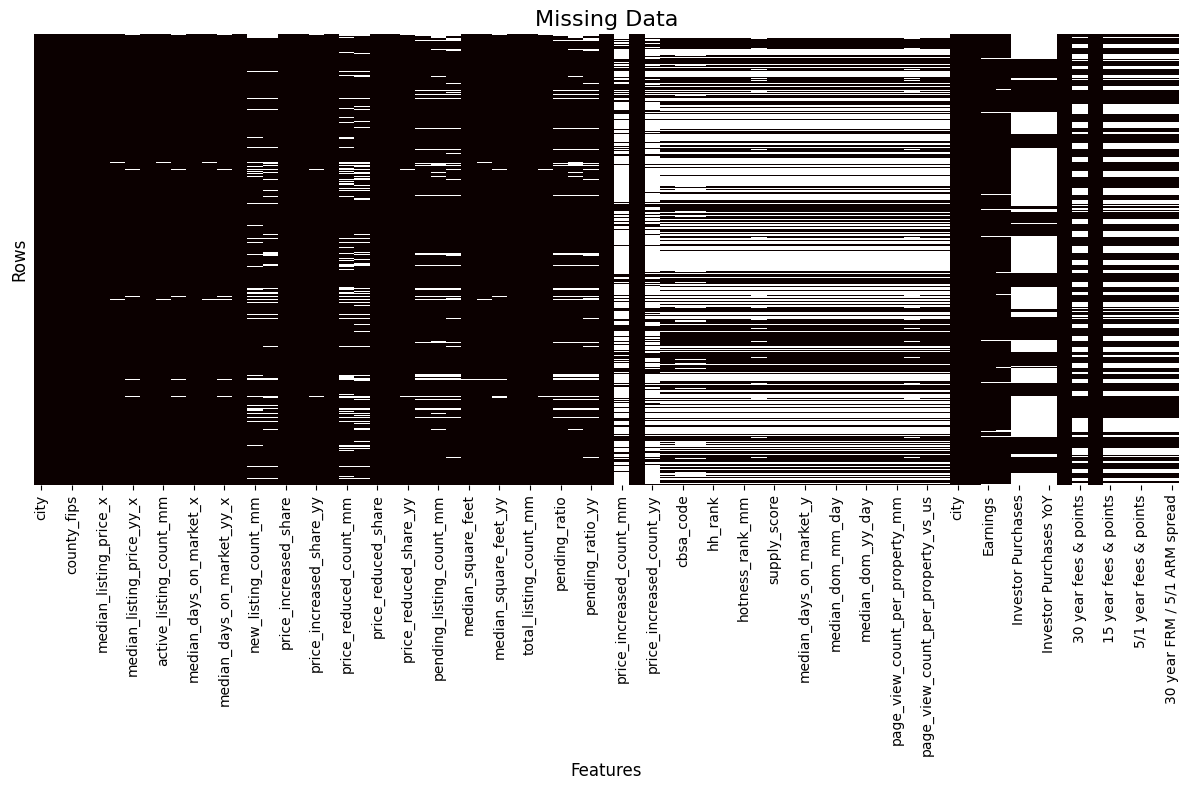

In [ ]:
# Create a heatmap showing the missing data of the reduced dataset
plt.figure(figsize=(12, 8))
# df_reduced.isnull() creates a boolean mask where True indicates missing values
sns.heatmap(df.isnull(), cbar=False, cmap='hot', yticklabels=False)
plt.title('Missing Data', fontsize=16)
plt.xlabel('Features', fontsize=12)
plt.ylabel('Rows', fontsize=12)
plt.tight_layout()
plt.show()

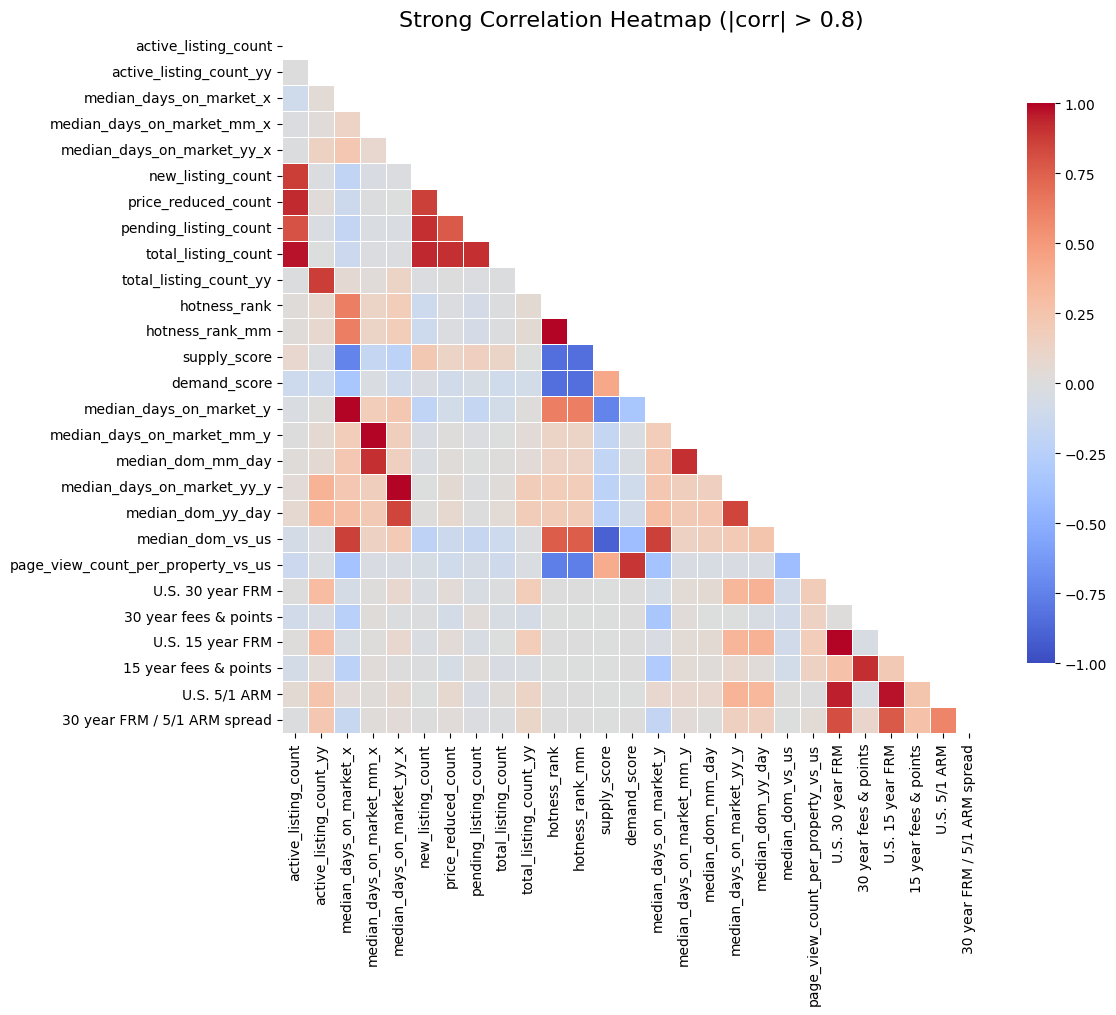

In [ ]:
columns_to_plot = df.columns

plt.figure(figsize=(12, 10))

# Compute correlation matrix
corr_matrix = df[columns_to_plot].corr(numeric_only=True)

# Create mask for strong correlations
strong_corr = (corr_matrix > 0.8) | (corr_matrix < -0.8)

# Remove self-correlation (diagonal)
np.fill_diagonal(strong_corr.values, False)

# Keep only columns that have at least one strong correlation
cols_to_keep = strong_corr.any(axis=0)

# Filter correlation matrix
filtered_corr_matrix = corr_matrix.loc[cols_to_keep, cols_to_keep]

# Mask upper triangle
mask = np.triu(np.ones_like(filtered_corr_matrix, dtype=bool))

# Plot
sns.heatmap(
    filtered_corr_matrix,
    mask=mask,
    annot=False,
    fmt=".2f",
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=.5,
    cbar_kws={"shrink": .8}
)

plt.title('Strong Correlation Heatmap (|corr| > 0.8)', fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
# From darts documentation 

# Constant settings from dart quick
# before starting, we define some constants
num_samples = 200

figsize = (9, 6)
lowest_q, low_q, high_q, highest_q = 0.01, 0.1, 0.9, 0.99
label_q_outer = f"{int(lowest_q * 100)}-{int(highest_q * 100)}th percentiles"
label_q_inner = f"{int(low_q * 100)}-{int(high_q * 100)}th percentiles"

In [ ]:
df['year'] = pd.to_datetime(df['date']).dt.year
df['month'] = pd.to_datetime(df['date']).dt.month

In [ ]:
#gathering holidays for df, creating a feature, and joining
us_holidays = holidays.US(years=df['year'].unique())

holiday_df = pd.DataFrame({
    "date": list(us_holidays.keys()),
    "is_holiday": 1
})

holiday_df['date'] = pd.to_datetime(holiday_df["date"])

df = pd.merge(df,holiday_df,how='left',on='date')


df['is_holiday'] = df['is_holiday'].fillna(0)

# Drop duplicate columns (keep first occurrence)
df = df.loc[:, ~df.columns.duplicated()]

#cleaning before model use
df['is_holiday'] = df['is_holiday'].astype('str')
df['month'] = df['month'].astype('str')

# Replace periods in column names with underscores
df.columns = [col.replace('.', '_') for col in df.columns]

# Drop columns with a high percentage of null values and store dropped columns in a DataFrame
null_threshold = 0.5  # Drop columns with more than 50% nulls (adjust as needed)
null_frac = df.isnull().mean()
cols_to_drop = null_frac[null_frac > null_threshold].index.tolist()
dropped_cols_df = pd.DataFrame({'dropped_column': cols_to_drop, 'null_fraction': null_frac[cols_to_drop].values})
df = df.drop(columns=cols_to_drop)
df = df.drop(columns=['county_fips','city','county_name_y'])

In [ ]:
# Choose the column to group by
group_col = ['state', 'year', 'month','is_holiday']

# Build aggregation dictionary
agg_dict = {}
for col in df.columns:
    if col in group_col:
        continue
    if pd.api.types.is_numeric_dtype(df[col]):
        agg_dict[col] = 'mean' 
    else:
        agg_dict[col] = 'max'

# Perform the groupby aggregation
df = df.groupby(group_col).agg(agg_dict).reset_index()

In [ ]:
max_prediction_length = 12
#Choose columns to exclude from time_varying_unknown_reals
cols_to_exclude = ['date', 'city', 'state','county_fips', 'median_listing_price_x','median_listing_price_mm_x','median_listing_price_yy_x']

# Only use numeric columns for time_varying_unknown_reals
numeric_cols = df.select_dtypes(include=[np.number]).columns
time_varying_unknown_reals = [col for col in numeric_cols if col not in cols_to_exclude]

remaining_cols = time_varying_unknown_reals

#reals = “how much?”
#categoricals = “which type?”

static_categoricals = ["state"]

time_varying_known_reals = ["date"]
time_varying_known_categoricals = ["is_holiday", "month"]
time_varying_unknown_categoricals = []


df['date'] = pd.to_datetime(df['date'])
Start_date = df['date'].min()

df["date"] = pd.to_datetime(df["date"], errors="coerce")
df = df.dropna(subset=["date"])
if not df.empty:
    df["time_idx"] = df["date"].dt.year * 12 + df["date"].dt.month
    df["time_idx"] -= df["time_idx"].min()
else:
    raise ValueError("DataFrame is empty after date conversion.")

training_cutoff = df["time_idx"].max() - max_prediction_length

# Consider the implications of this imputation

In [ ]:
# Interpolate missing values for all numeric columns
df.interpolate(method='linear', limit_direction='both', inplace=True)

# As a backup, fill any remaining NAs with the previous value, then next value
df.fillna(method='ffill', inplace=True)
df.fillna(method='bfill', inplace=True)

In [ ]:
training = TimeSeriesDataSet(
    df[lambda x: x['time_idx'] <= training_cutoff],
    time_idx="time_idx",
    target="median_listing_price_x",
    group_ids=["state"],
    min_encoder_length=36// 2,
    max_encoder_length=36 , #3 years
    min_prediction_length=1,
    max_prediction_length=12,
    static_categoricals=["state"],
    time_varying_known_categoricals=["is_holiday", "month"], #treat these like labels
    time_varying_known_reals=["date"],
    time_varying_unknown_categoricals=[],
    time_varying_unknown_reals=remaining_cols,
    target_normalizer=GroupNormalizer(
        groups=["state"], transformation="softplus"
    ),  # use softplus and normalize by group
    add_relative_time_idx=True,
    add_target_scales=True,
    add_encoder_length=True,
    allow_missing_timesteps=True, #review data for missing timesteps
)

# create validation set (predict=True) which means to predict the last max_prediction_length points in time
# for each series
validation = TimeSeriesDataSet.from_dataset(
    training, df, predict=True, stop_randomization=True
)
# create dataloaders for model
batch_size = 128  # set this between 32 to 128
train_dataloader = training.to_dataloader(
    train=True, batch_size=batch_size, num_workers=0
)
val_dataloader = validation.to_dataloader(
    train=False, batch_size=batch_size * 10, num_workers=0
)

# Create baseline model

# Need to work through this

In [ ]:
# calculate baseline mean absolute error, i.e. predict next value as the last available value from the history
baseline_predictions = Baseline().predict(val_dataloader, return_y=True)

device = baseline_predictions.output.device
output = baseline_predictions.output
y = baseline_predictions.y
if isinstance(output, tuple):
    output = output[0]
if isinstance(y, tuple):
    y = y[0]
output = output.to(device)
y = y.to(device)
mae_metric = MAE().to(device)
mae_metric(output, y)

tensor(12515.3389)

# Train Temporal Fusion Transformer

In [ ]:
# configure network and trainer
pl.seed_everything(42)
trainer = pl.Trainer(
    accelerator="cpu",
    # clipping gradients is a hyperparameter and important to prevent divergance
    # of the gradient for recurrent neural networks
    gradient_clip_val=0.1,
)


tft = TemporalFusionTransformer.from_dataset(
    training,
    # not meaningful for finding the learning rate but otherwise very important
    learning_rate=0.03,
    hidden_size=8,  # most important hyperparameter apart from learning rate
    # number of attention heads. Set to up to 4 for large datasets
    attention_head_size=1,
    dropout=0.1,  # between 0.1 and 0.3 are good values
    hidden_continuous_size=8,  # set to <= hidden_size
    loss=QuantileLoss(),
    optimizer="ranger",
    # reduce learning rate if no improvement in validation loss after x epochs
    # reduce_on_plateau_patience=1000,
)
print(f"Number of parameters in network: {tft.size() / 1e3:.1f}k")

Number of parameters in network: 30.7k


# Train model

In [ ]:
# configure network and trainer
early_stop_callback = EarlyStopping(
    monitor="val_loss", min_delta=1e-4, patience=10, verbose=False, mode="min"
)
lr_logger = LearningRateMonitor()  # log the learning rate
logger = TensorBoardLogger("lightning_logs")  # logging results to a tensorboard

trainer = pl.Trainer(
    max_epochs=50,
    accelerator="cpu",
    enable_model_summary=True,
    gradient_clip_val=0.1,
    limit_train_batches=50,  # coment in for training, running valiation every 30 batches
    # fast_dev_run=True,  # comment in to check that networkor dataset has no serious bugs
    callbacks=[lr_logger, early_stop_callback],
    logger=logger,
)

tft = TemporalFusionTransformer.from_dataset(
    training,
    learning_rate=0.03,
    hidden_size=16,
    attention_head_size=2,
    dropout=0.1,
    hidden_continuous_size=8,
    loss=QuantileLoss(),
    log_interval=10,  # uncomment for learning rate finder and otherwise, e.g. to 10 for logging every 10 batches
    optimizer="ranger",
    reduce_on_plateau_patience=4,
)
print(f"Number of parameters in network: {tft.size() / 1e3:.1f}k")

Number of parameters in network: 59.8k


In [ ]:
# For a PyTorch tensor
import torch
tensor = torch.randn(10, 5)
print("Tensor length (first dimension):", len(tensor))

# For a DataLoader or Dataset
from torch.utils.data import DataLoader, TensorDataset
dataset = TensorDataset(torch.randn(100, 3))
dataloader = DataLoader(dataset, batch_size=16)
print("Dataset length:", len(dataset))
print("Number of batches in DataLoader:", len(dataloader))

Tensor length (first dimension): 10
Dataset length: 100
Number of batches in DataLoader: 7


In [ ]:
# fit network
trainer.fit(
    tft,
    train_dataloaders=train_dataloader,
    val_dataloaders=val_dataloader,
)

┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                               ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ loss                               │ QuantileLoss                    │      0 │ train │     0 │
│ 1  │ logging_metrics                    │ ModuleList                      │      0 │ train │     0 │
│ 2  │ input_embeddings                   │ MultiEmbedding                  │    788 │ train │     0 │
│ 3  │ prescalers                         │ ModuleDict                      │    992 │ train │     0 │
│ 4  │ static_variable_selection          │ VariableSelectionNetwork        │  1.9 K │ train │     0 │
│ 5  │ encoder_variable_selection         │ VariableSelectionNetwork        │ 41.8 K │ train │     0 │
│ 6  │ decoder_variable_selection         │ VariableSelectionNetwork        │  1.4 K │ train │     0 │
│ 7  │ static_context_variable_selection  │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 8  │ static_context_initial_hidden_lstm │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 9  │ static_context_initial_cell_lstm   │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 10 │ static_context_enrichment          │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 11 │ lstm_encoder                       │ LSTM                            │  2.2 K │ train │     0 │
│ 12 │ lstm_decoder                       │ LSTM                            │  2.2 K │ train │     0 │
│ 13 │ post_lstm_gate_encoder             │ GatedLinearUnit                 │    544 │ train │     0 │
│ 14 │ post_lstm_add_norm_encoder         │ AddNorm                         │     32 │ train │     0 │
│ 15 │ static_enrichment                  │ GatedResidualNetwork            │  1.4 K │ train │     0 │
│ 16 │ multihead_attn                     │ InterpretableMultiHeadAttention │    808 │ train │     0 │
│ 17 │ post_attn_gate_norm                │ GateAddNorm                     │    576 │ train │     0 │
│ 18 │ pos_wise_ff                        │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 19 │ pre_output_gate_norm               │ GateAddNorm                     │    576 │ train │     0 │
│ 20 │ output_layer                       │ Linear                          │    119 │ train │     0 │
└────┴────────────────────────────────────┴─────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 59.8 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 59.8 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 1138                                                                                        
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

In [ ]:
trainer.save('../src/model_pt/tft_housing.pt')

AttributeError: 'Trainer' object has no attribute 'save'

# Tune hyperparameters

In [ ]:
# create study
study = optimize_hyperparameters(
    train_dataloader,
    val_dataloader,
    model_path="optuna_test",
    n_trials=200,
    max_epochs=50,
    gradient_clip_val_range=(0.01, 1.0),
    hidden_size_range=(8, 128),
    hidden_continuous_size_range=(8, 128),
    attention_head_size_range=(1, 4),
    learning_rate_range=(0.001, 0.1),
    dropout_range=(0.1, 0.3),
    trainer_kwargs=dict(limit_train_batches=30),
    reduce_on_plateau_patience=4,
    use_learning_rate_finder=False,  # use Optuna to find ideal learning rate or use in-built learning rate finder
)

# save study results - also we can resume tuning at a later point in time
with open("test_study.pkl", "wb") as fout:
    pickle.dump(study, fout)

# show best hyperparameters
print(study.best_trial.params)

SystemExit: 1

Evaluate performance

In [ ]:
# load the best model according to the validation loss
# (given that we use early stopping, this is not necessarily the last epoch)
best_model_path = trainer.checkpoint_callback.best_model_path
best_tft = TemporalFusionTransformer.load_from_checkpoint(best_model_path)

In [ ]:
# calcualte mean absolute error on validation set
predictions = best_tft.predict(
    val_dataloader,
    return_y=True,
    trainer_kwargs=dict(accelerator="cpu")
    
)

print("MAE:", MAE()(predictions.output, predictions.y))
print("MAPE:", MAPE()(predictions.output, predictions.y))

NameError: name 'best_tft' is not defined

In [ ]:
# raw predictions are a dictionary from which all kind of information including quantiles can be extracted
raw_predictions = best_tft.predict(
    val_dataloader, mode="raw",
    return_x=True,
    trainer_kwargs=dict(accelerator="cpu")
)

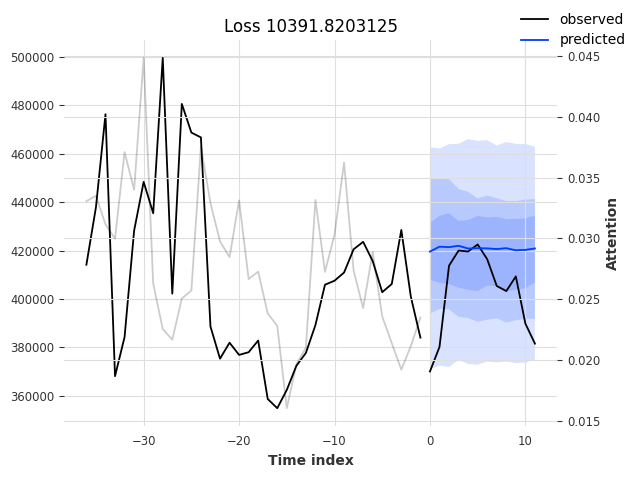

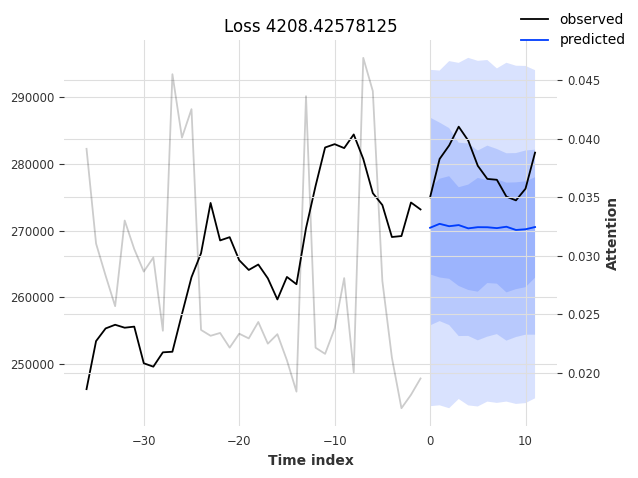

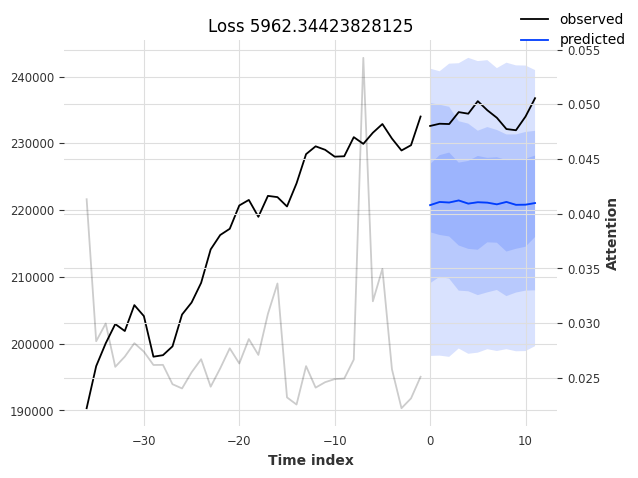

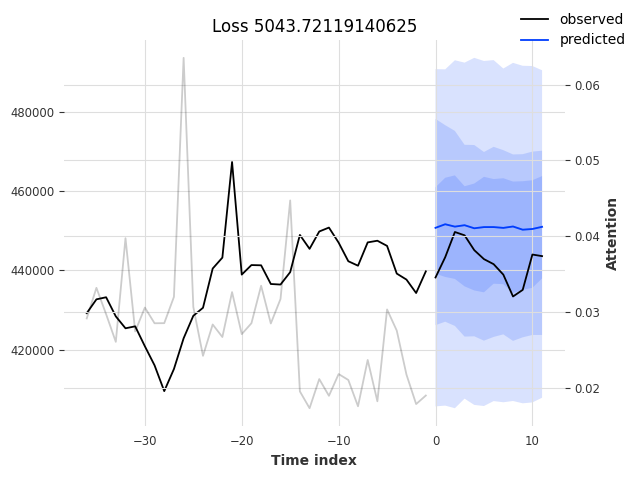

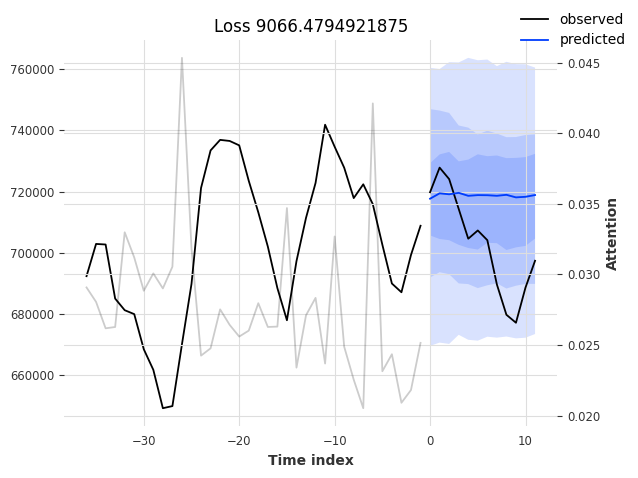

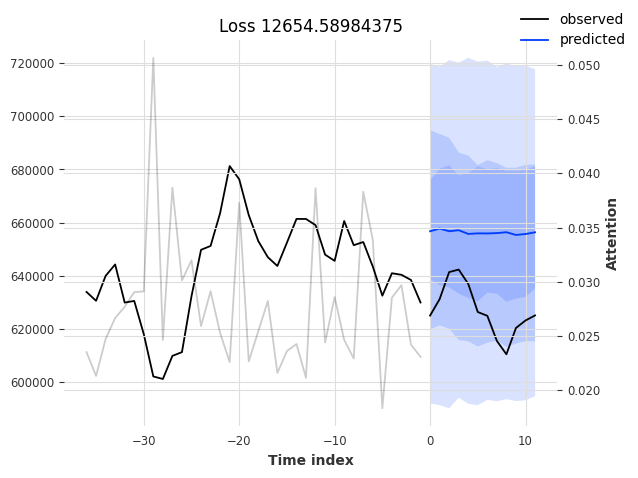

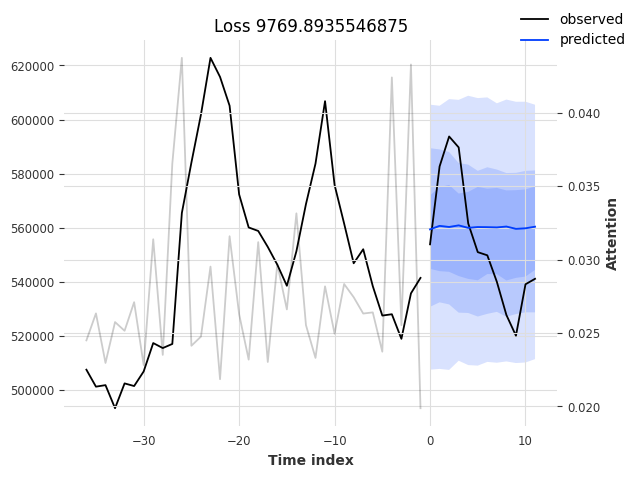

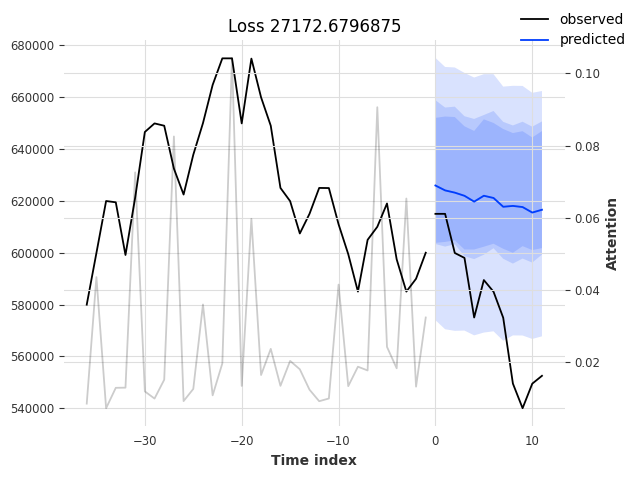

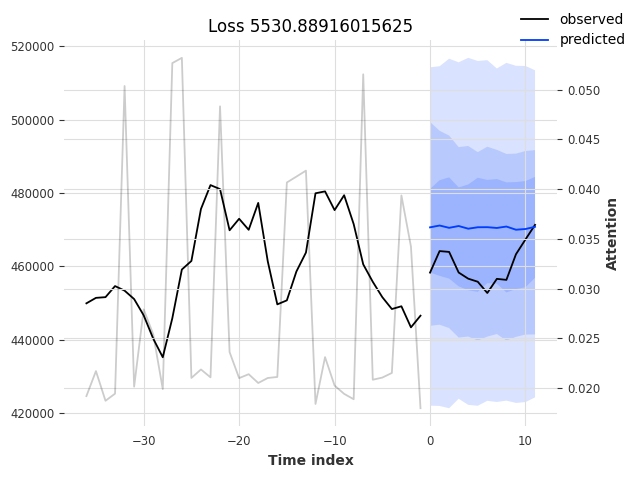

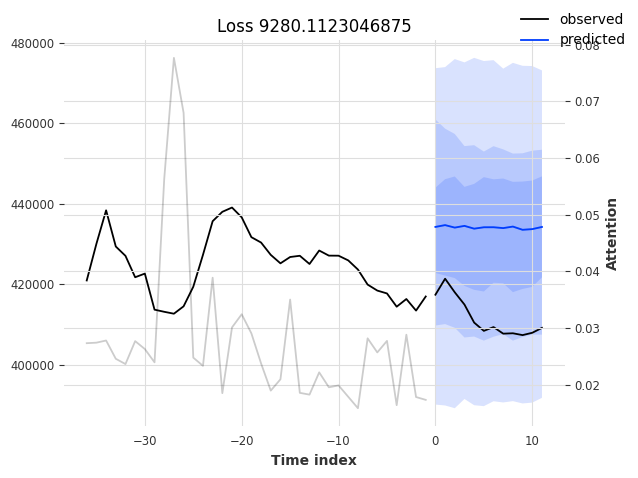

In [ ]:
for idx in range(10):  # plot 10 examples
    best_tft.plot_prediction(
        raw_predictions.x,
        raw_predictions.output,
        idx=idx,
        add_loss_to_title=True
    )


Worst Proformers

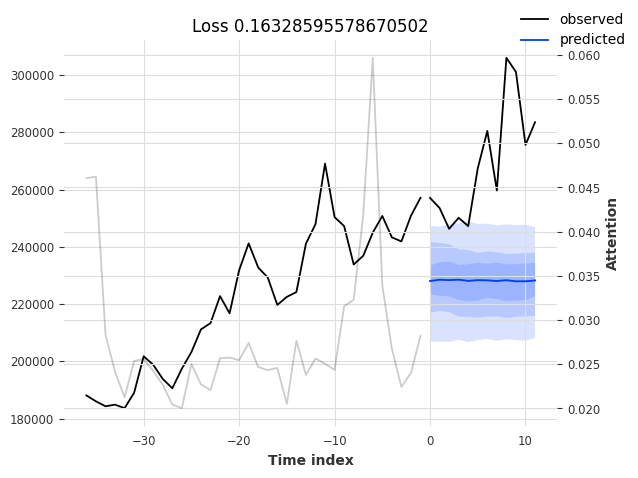

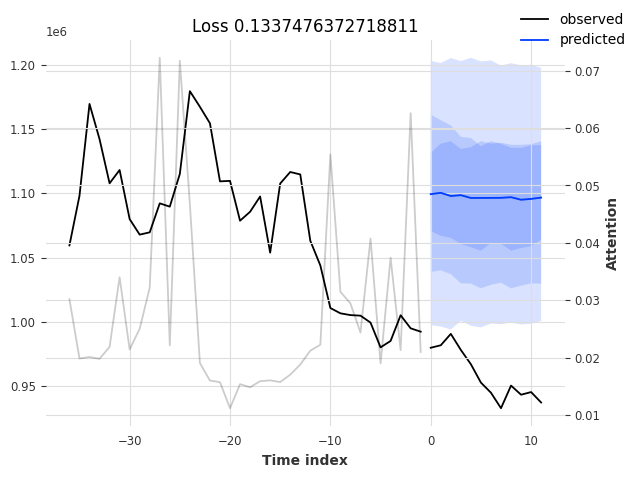

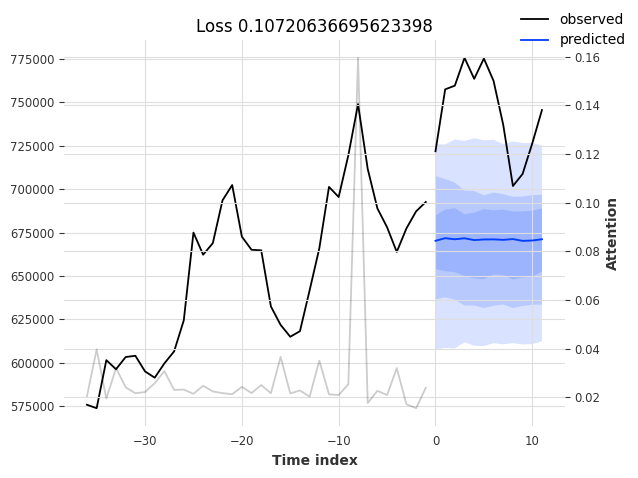

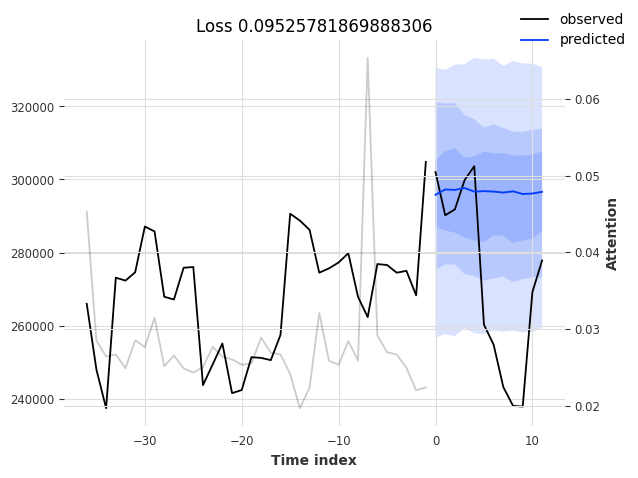

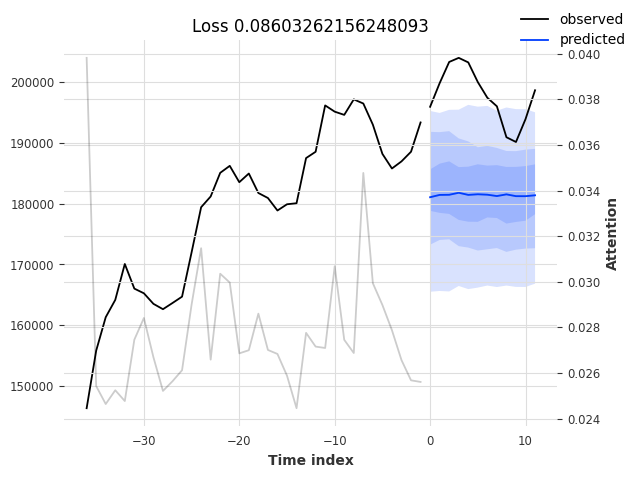

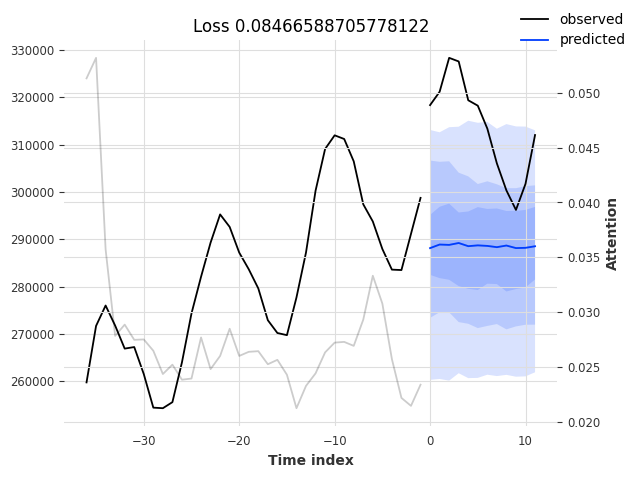

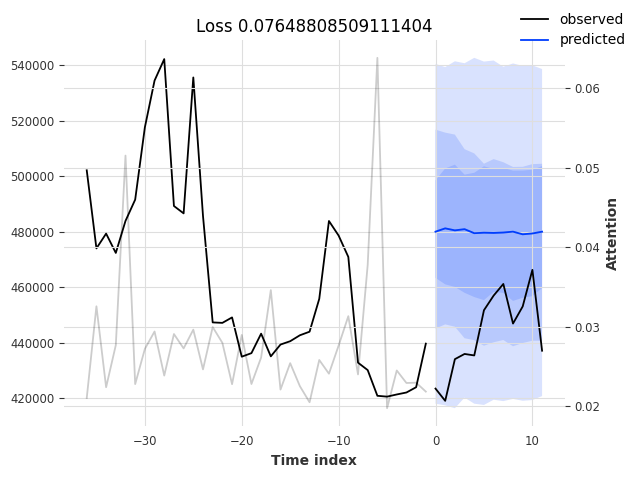

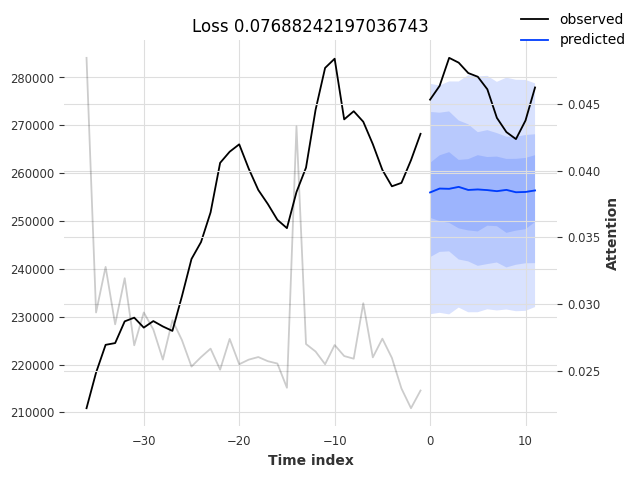

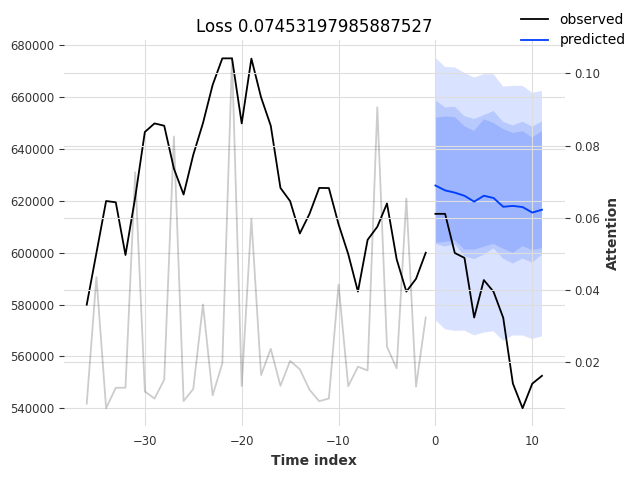

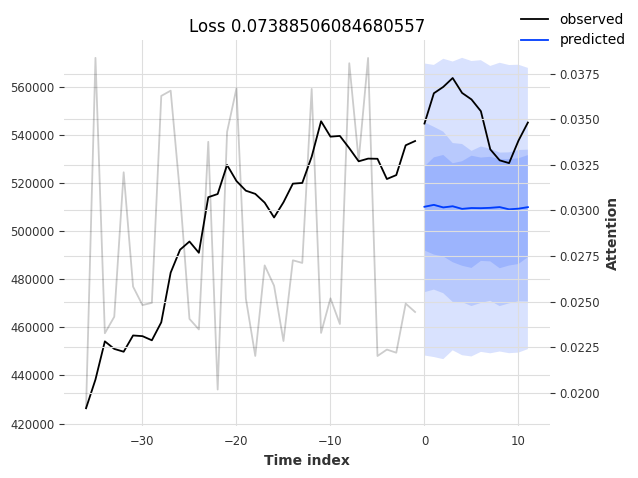

In [ ]:
# calcualte metric by which to display
predictions = best_tft.predict(
    val_dataloader, return_y=True, trainer_kwargs=dict(accelerator="cpu")
)
mean_losses = SMAPE(reduction="none").loss(predictions.output, predictions.y[0]).mean(1)
indices = mean_losses.argsort(descending=True)  # sort losses
for idx in range(10):  # plot 10 examples
    best_tft.plot_prediction(
        raw_predictions.x,
        raw_predictions.output,
        idx=indices[idx],
        add_loss_to_title=SMAPE(quantiles=best_tft.loss.quantiles),
    )

Actuals vs predictions by variables

{'encoder_length': <Figure size 1000x500 with 2 Axes>,
 'median_listing_price_x_center': <Figure size 1000x500 with 2 Axes>,
 'median_listing_price_x_scale': <Figure size 1000x500 with 2 Axes>,
 'date': <Figure size 1000x500 with 2 Axes>,
 'relative_time_idx': <Figure size 1000x500 with 2 Axes>,
 'year': <Figure size 1000x500 with 2 Axes>,
 'active_listing_count': <Figure size 1000x500 with 2 Axes>,
 'active_listing_count_mm': <Figure size 1000x500 with 2 Axes>,
 'active_listing_count_yy': <Figure size 1000x500 with 2 Axes>,
 'median_days_on_market_x': <Figure size 1000x500 with 2 Axes>,
 'median_days_on_market_mm_x': <Figure size 1000x500 with 2 Axes>,
 'median_days_on_market_yy_x': <Figure size 1000x500 with 2 Axes>,
 'new_listing_count': <Figure size 1000x500 with 2 Axes>,
 'new_listing_count_mm': <Figure size 1000x500 with 2 Axes>,
 'new_listing_count_yy': <Figure size 1000x500 with 2 Axes>,
 'price_increased_share': <Figure size 1000x500 with 2 Axes>,
 'price_increased_share_mm': 

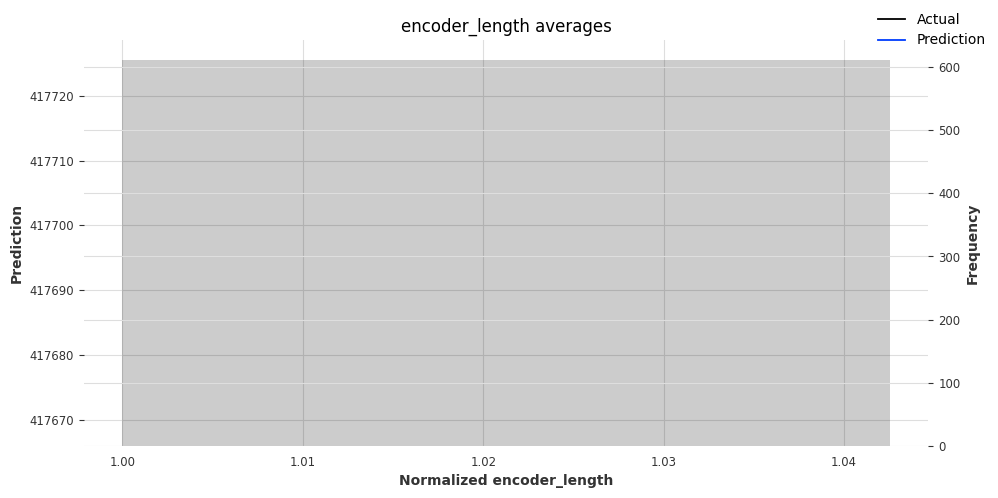

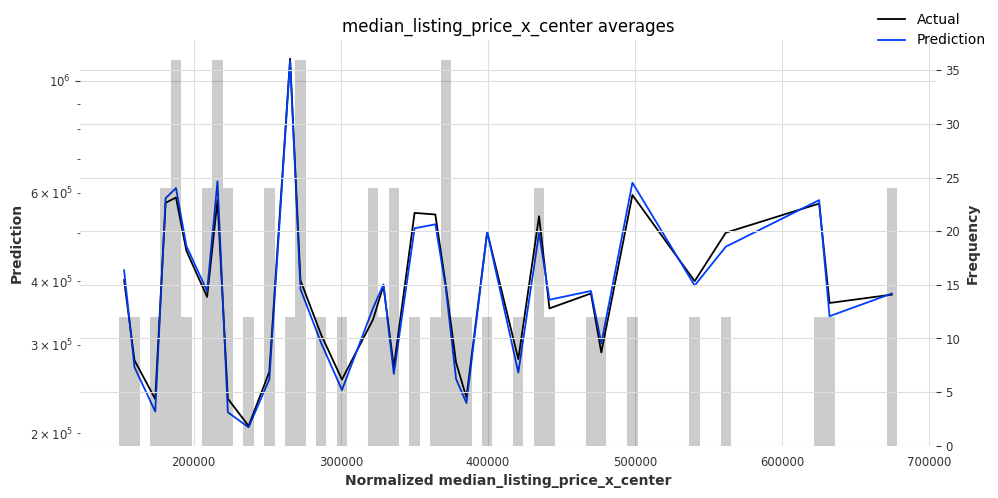

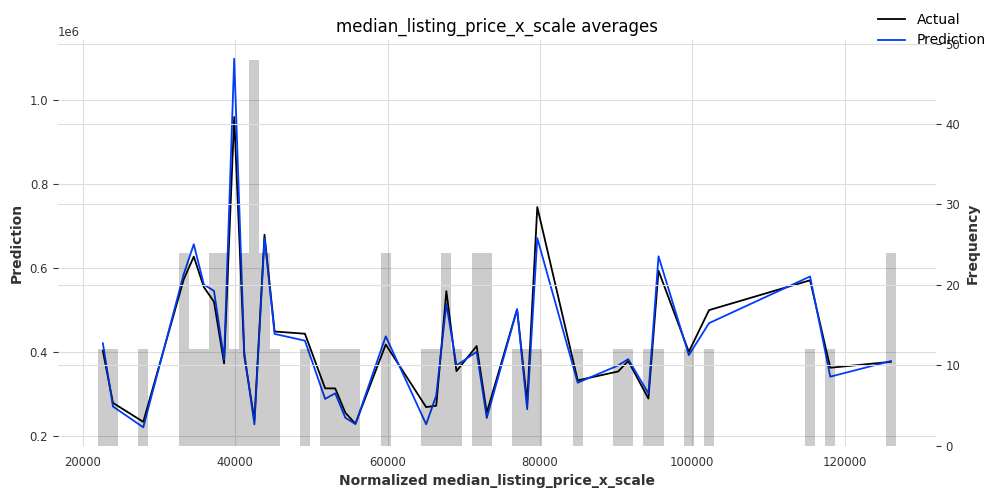

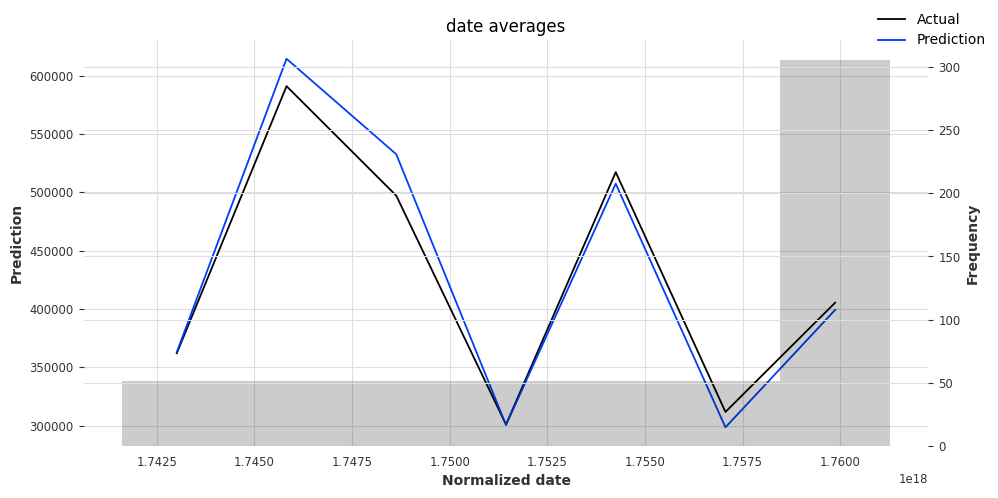

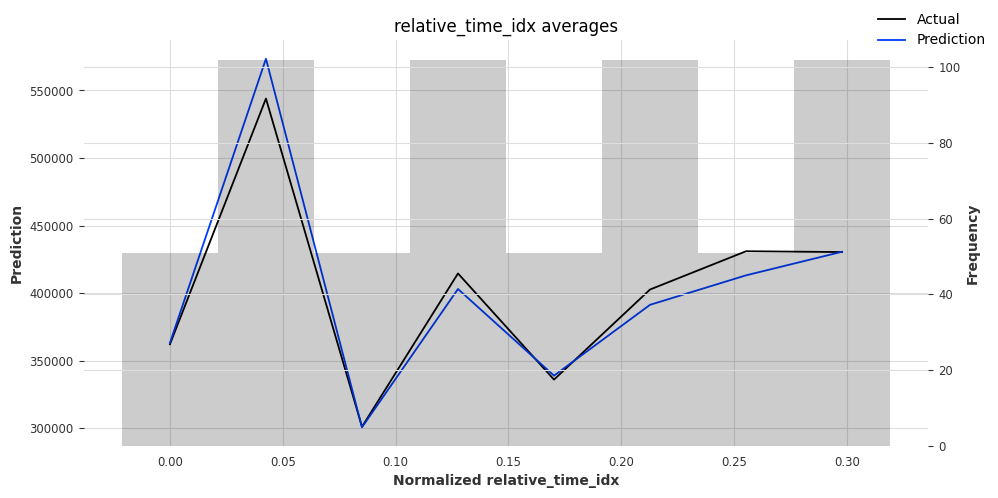

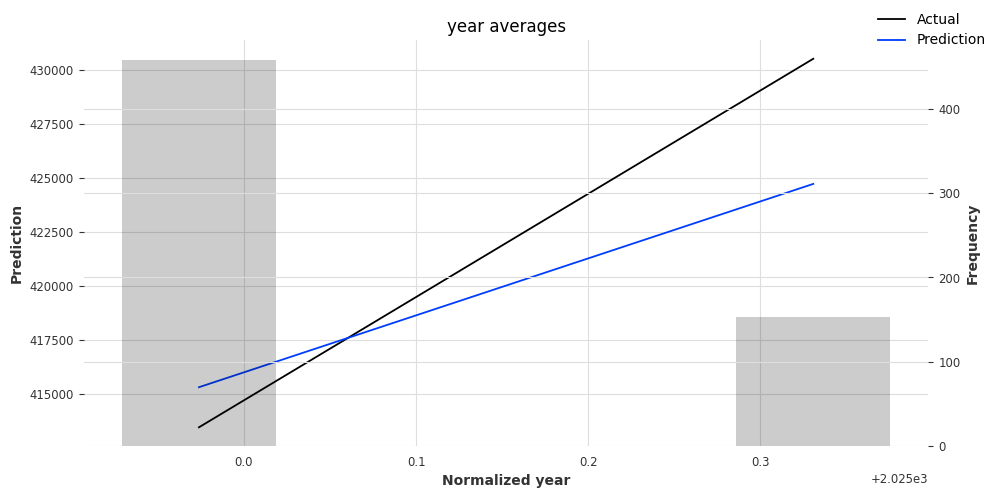

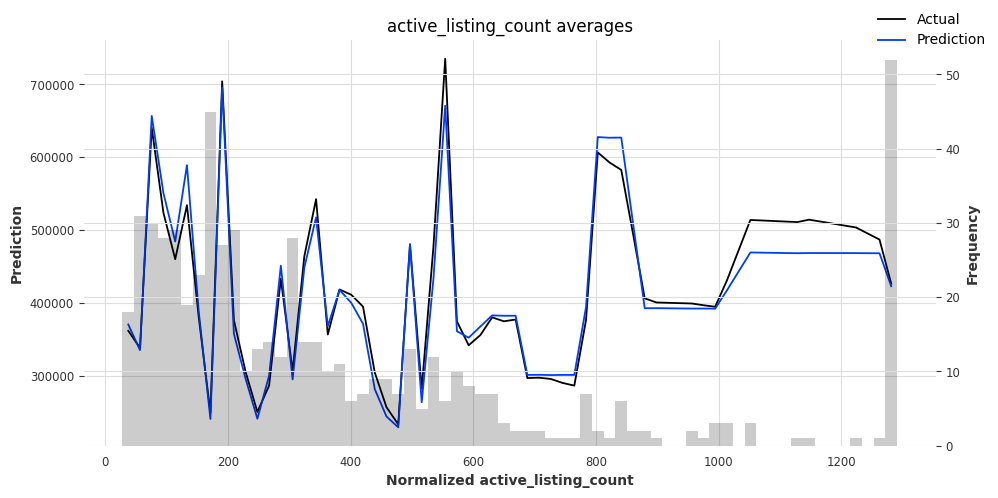

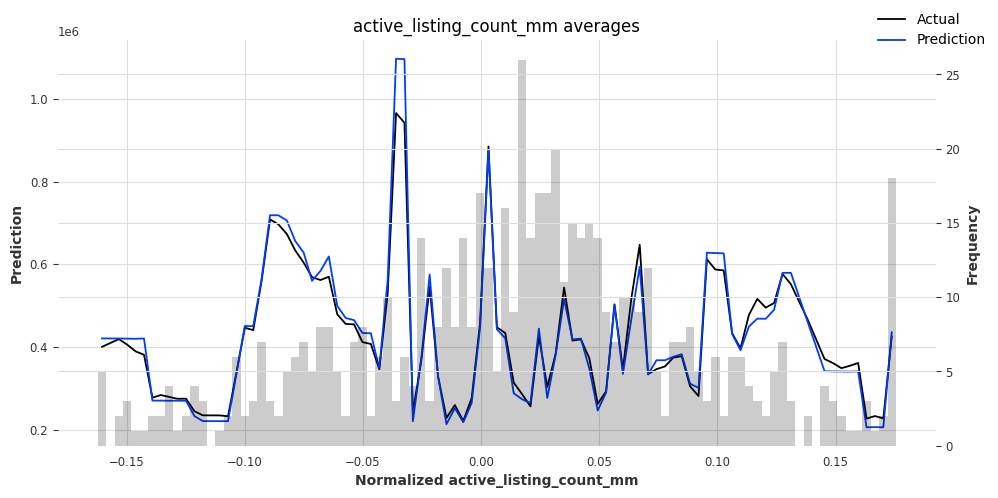

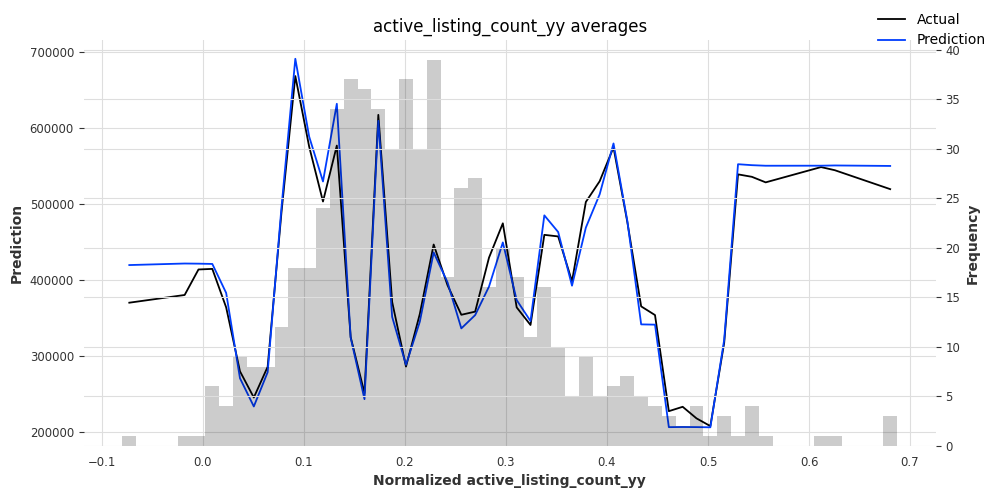

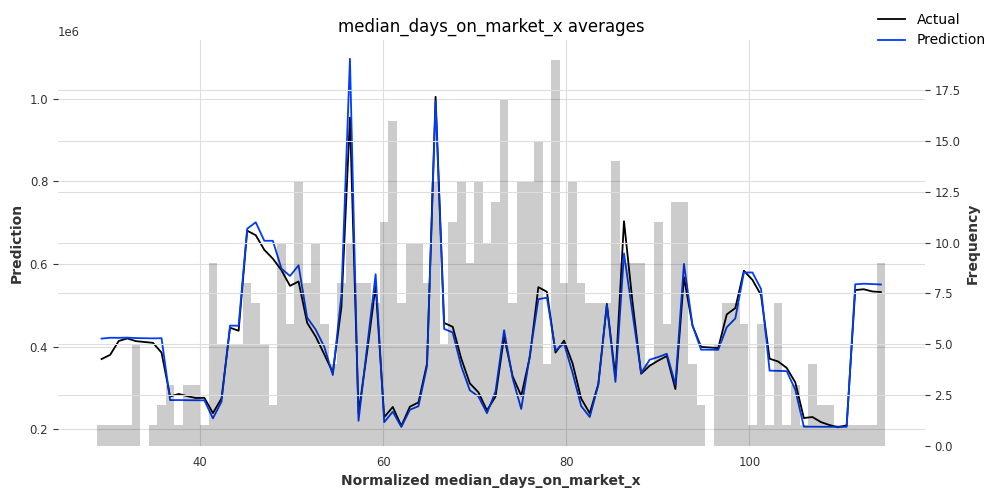

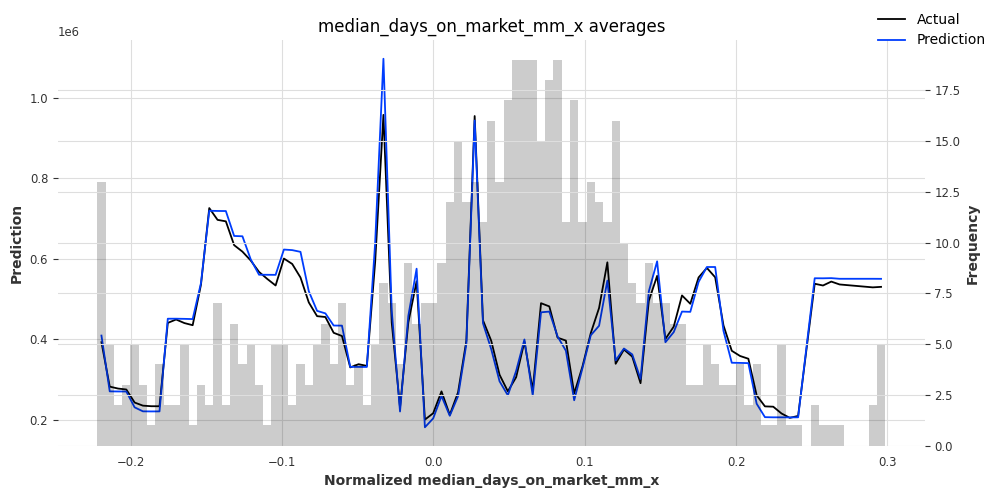

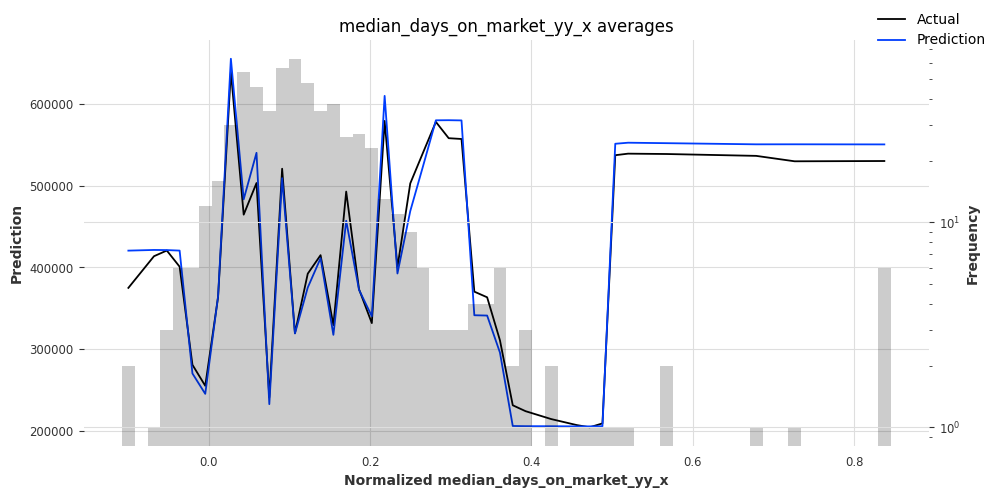

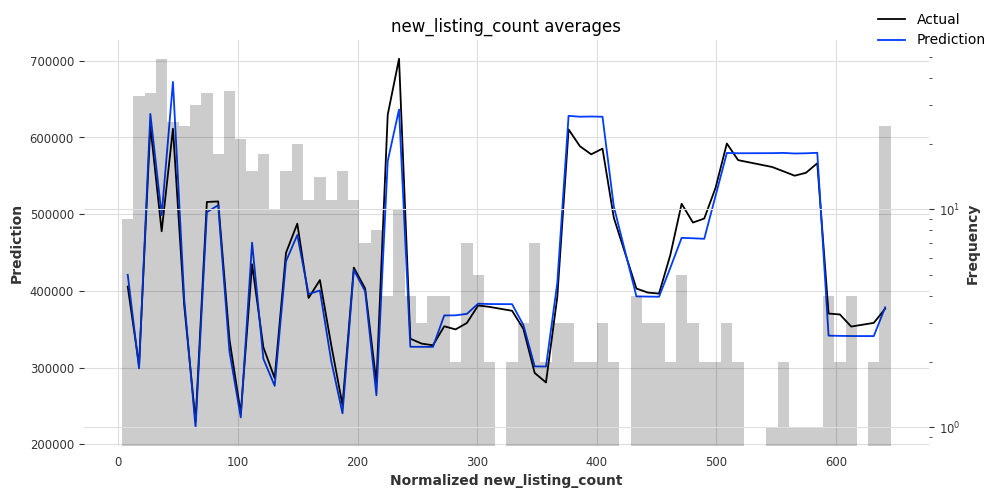

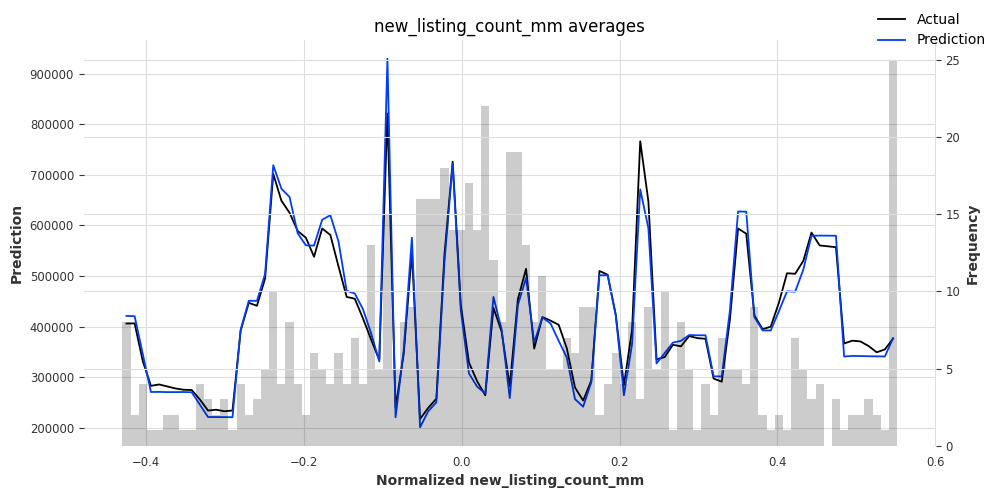

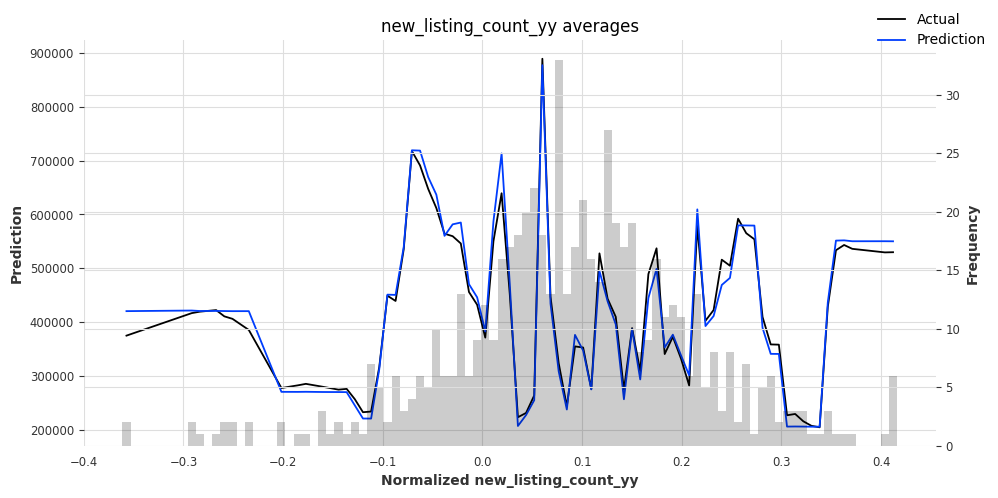

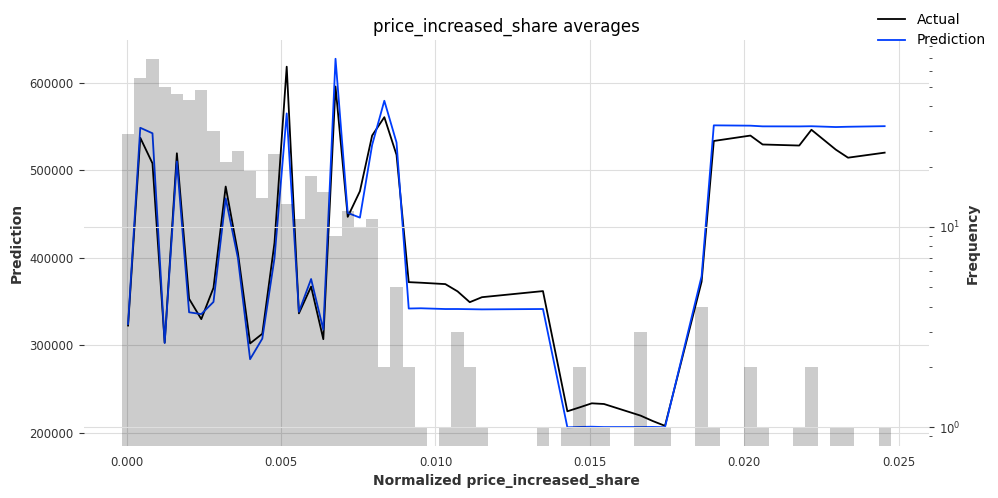

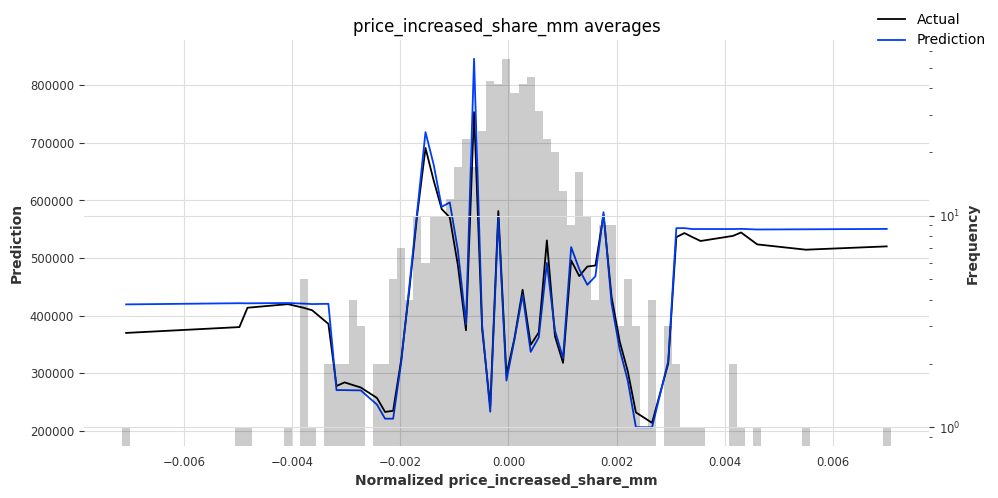

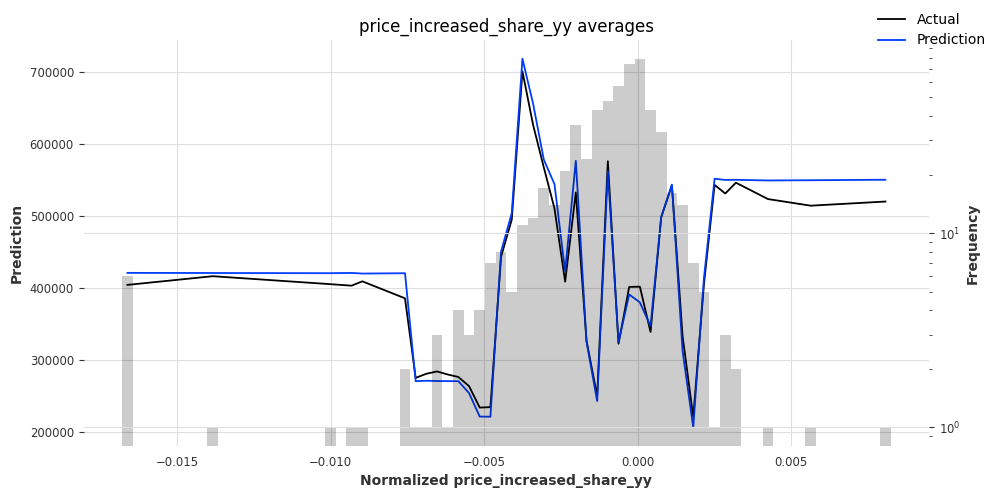

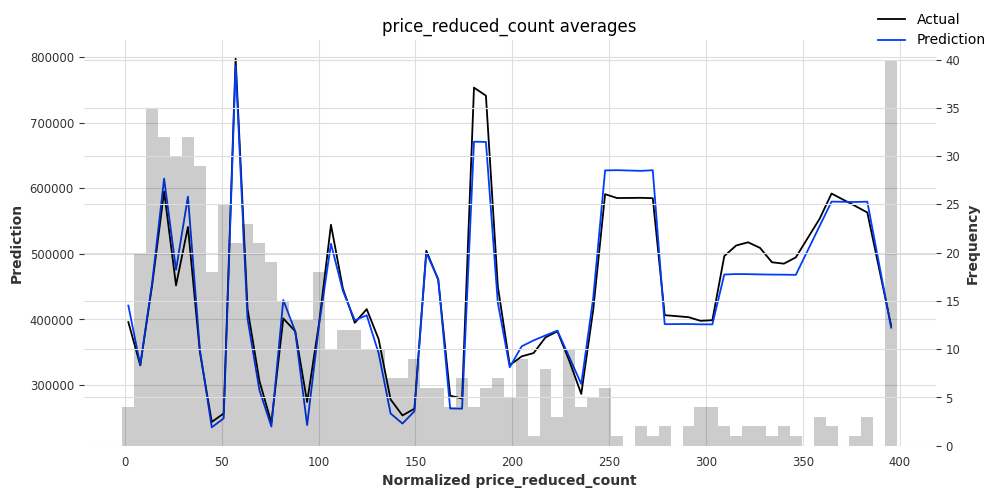

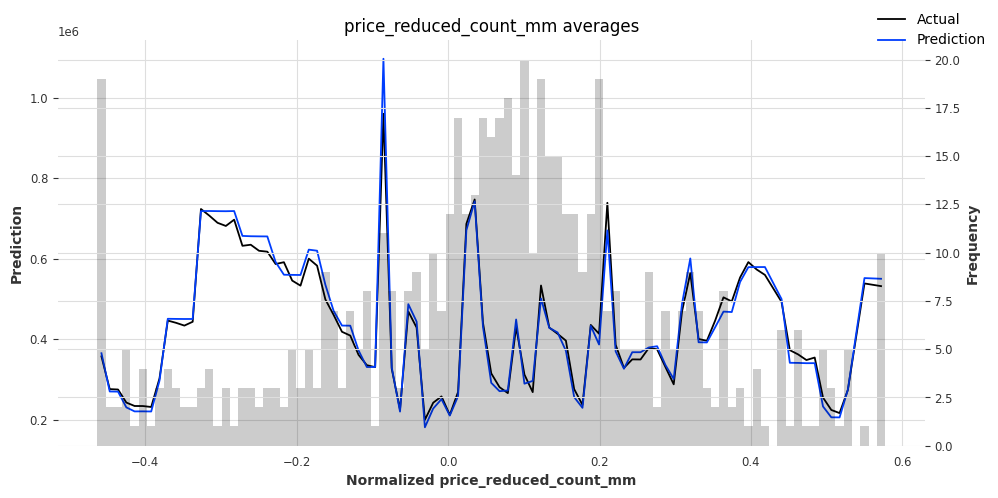

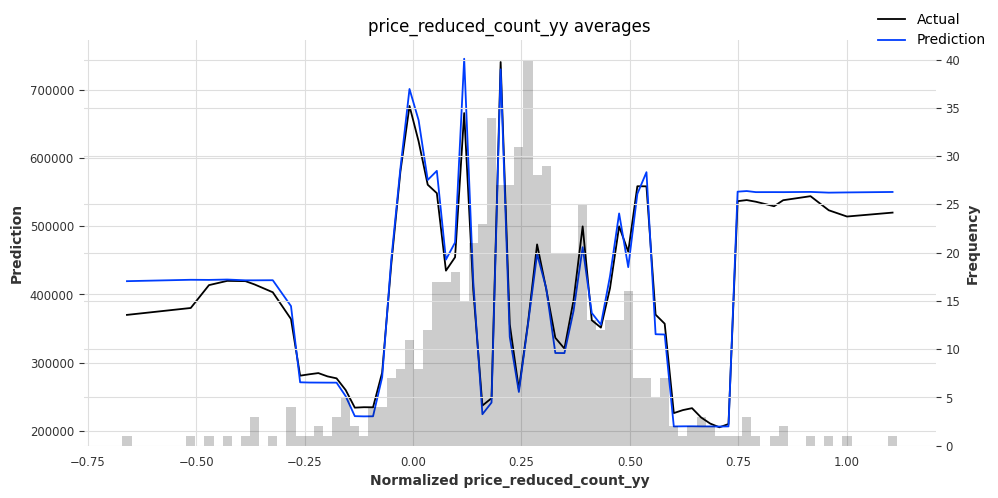

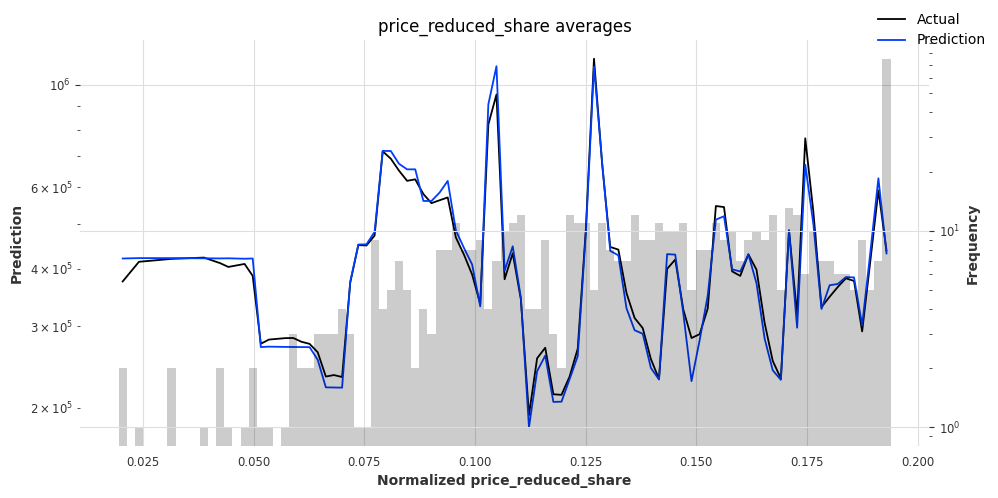

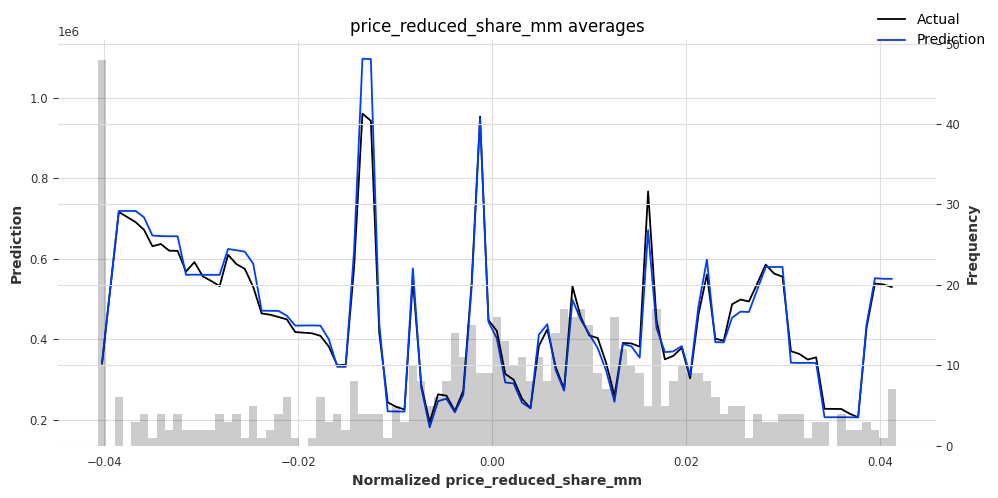

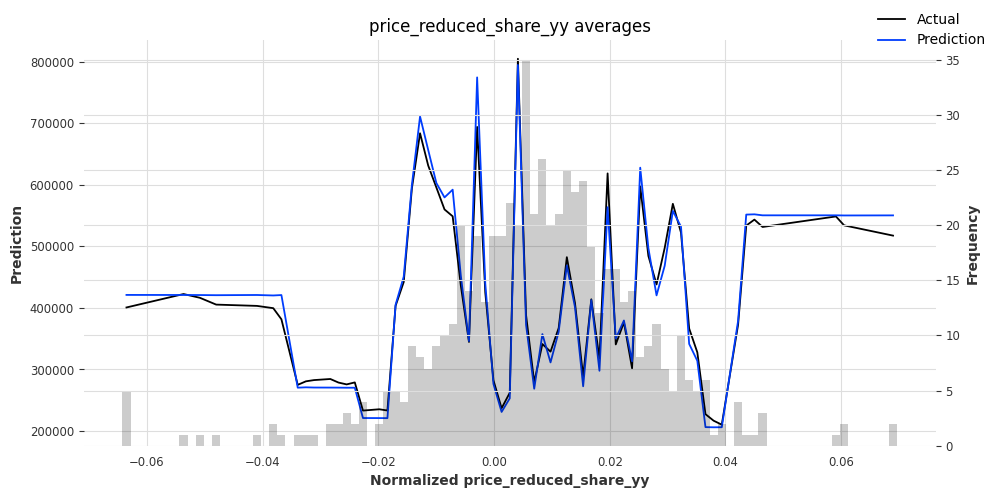

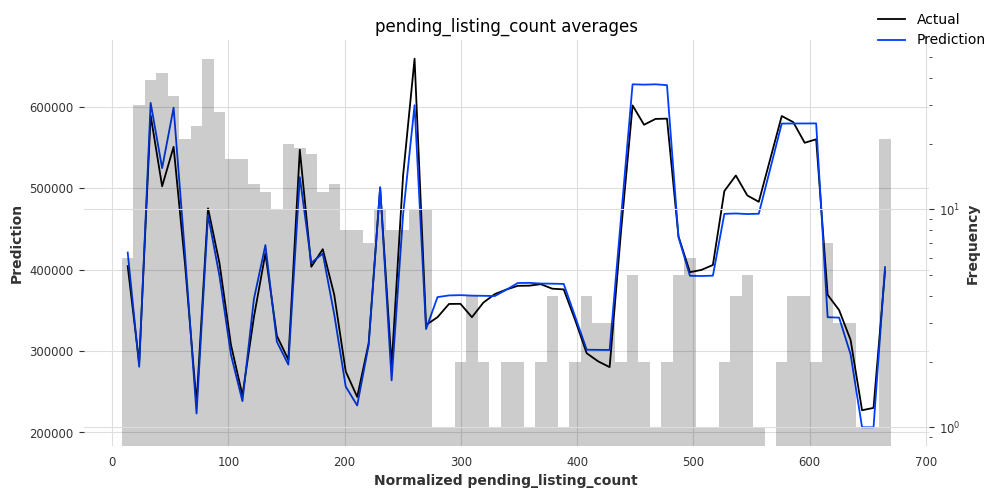

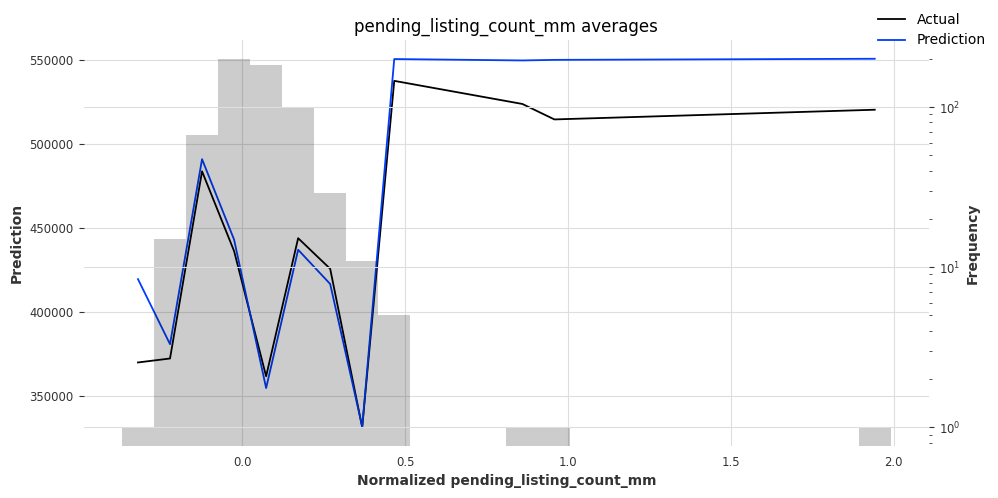

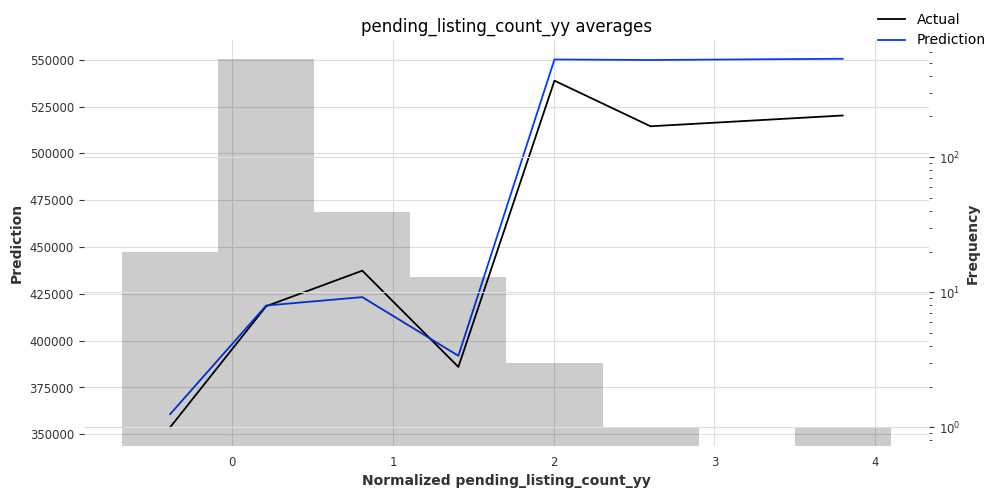

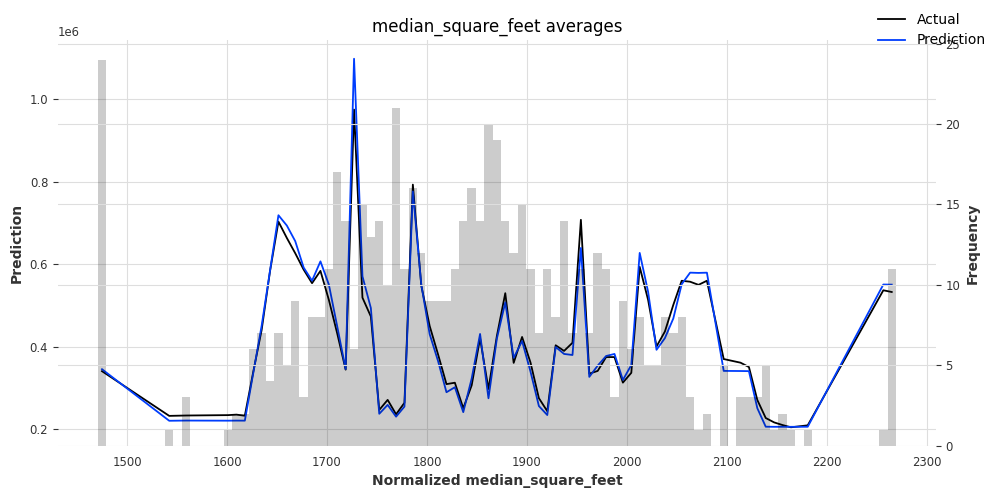

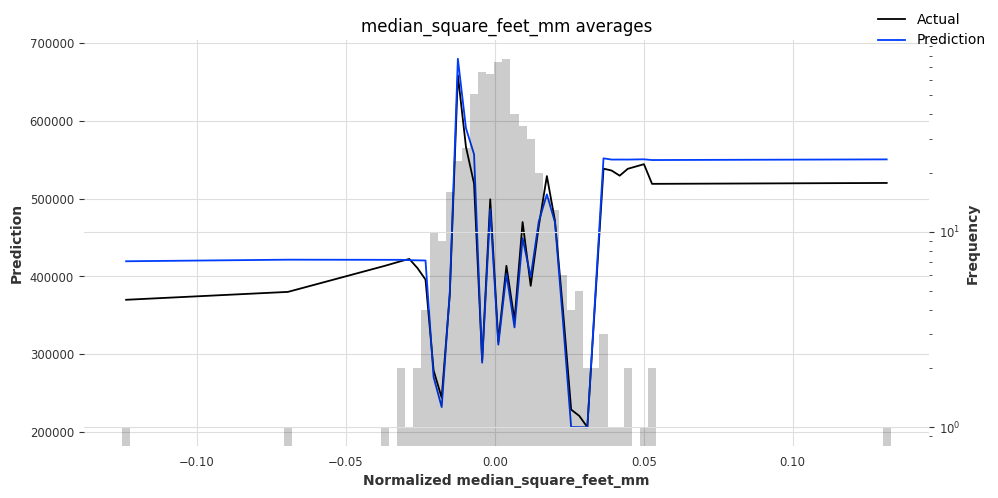

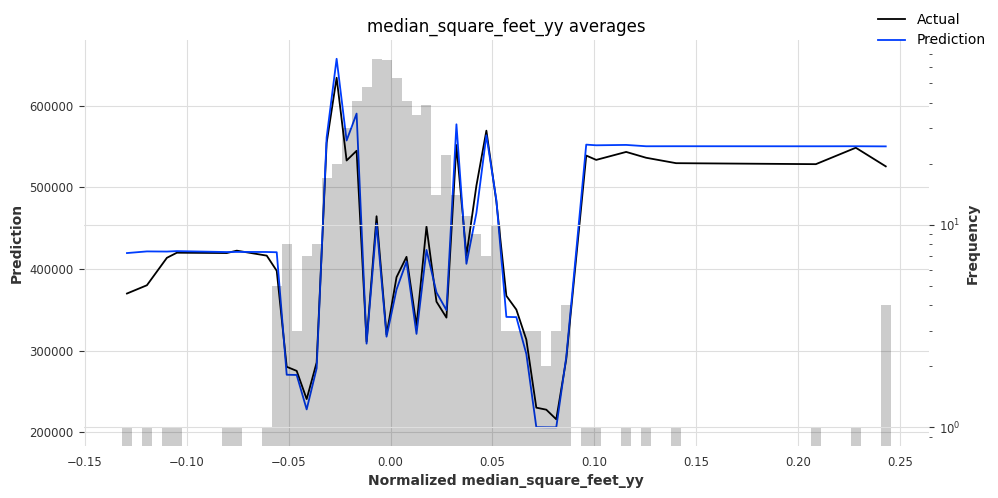

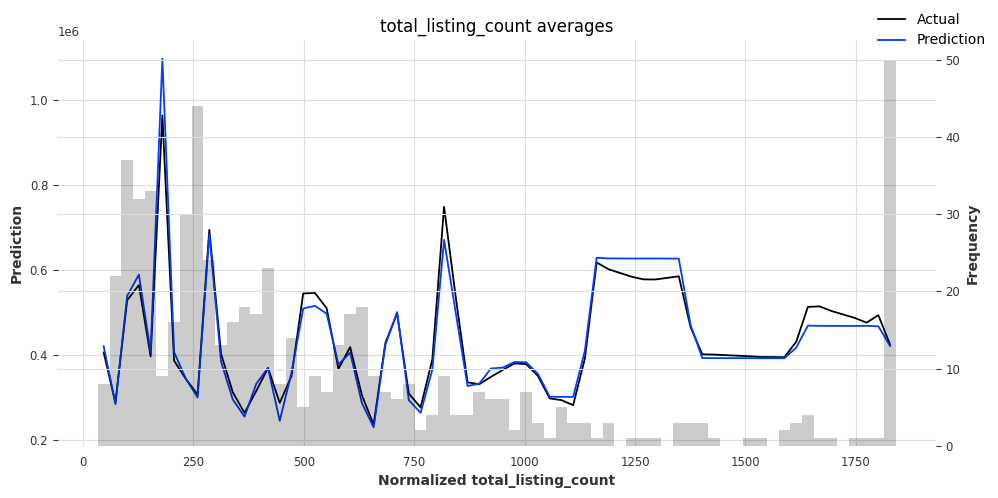

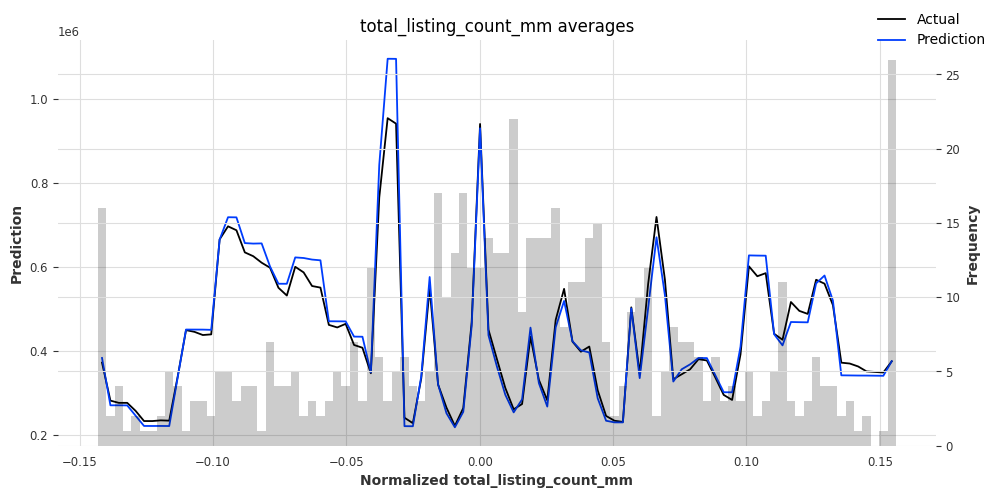

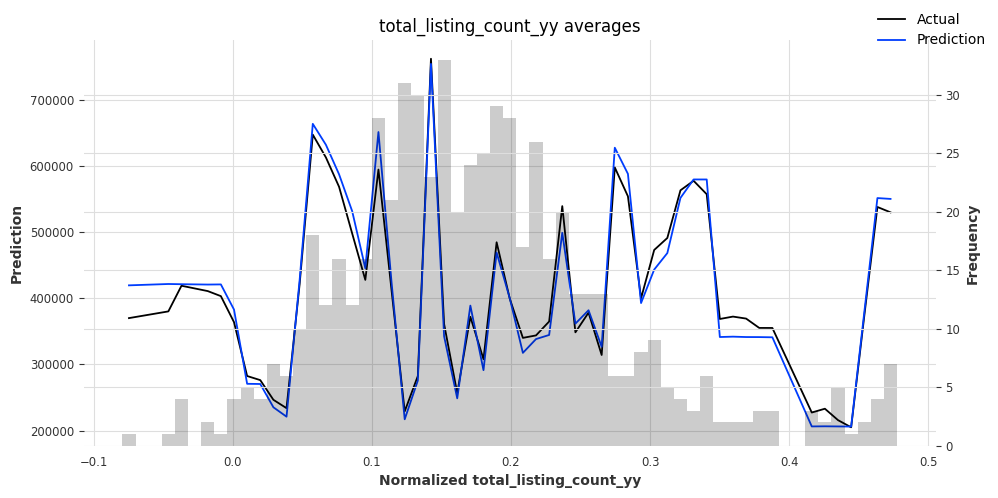

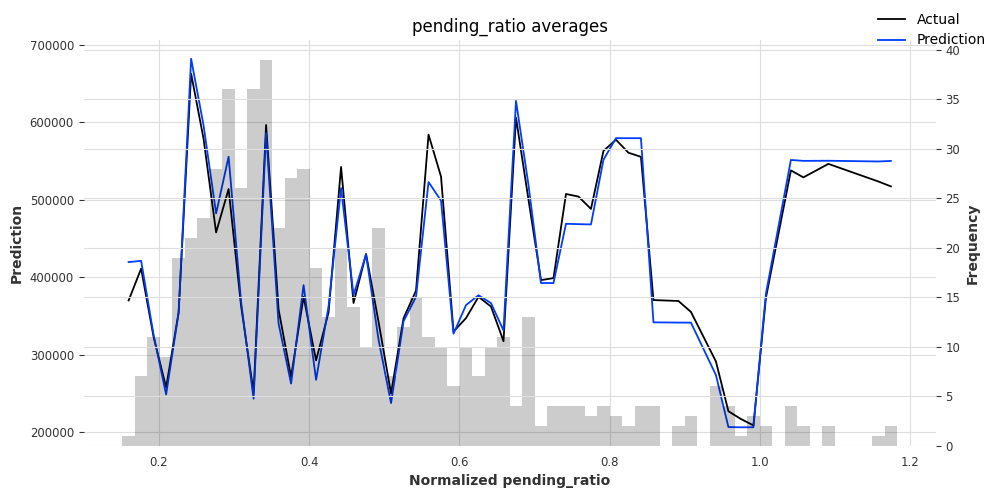

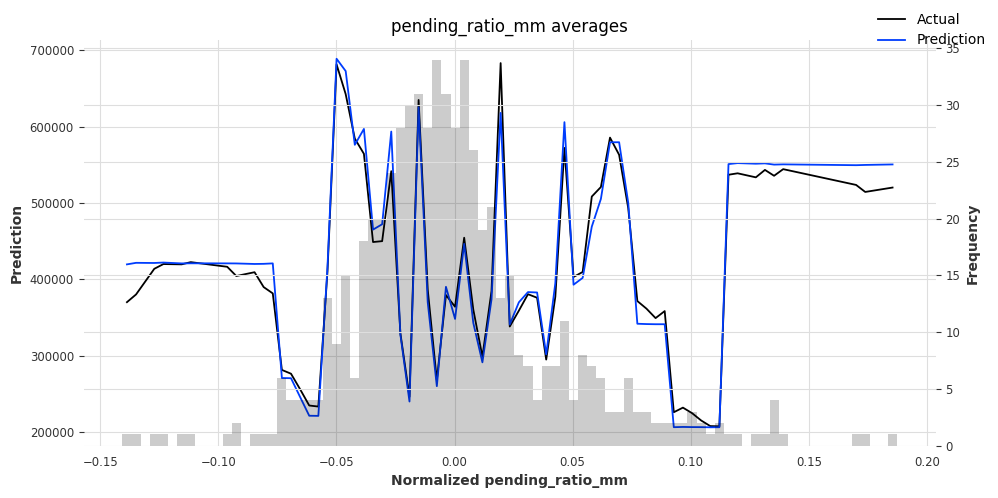

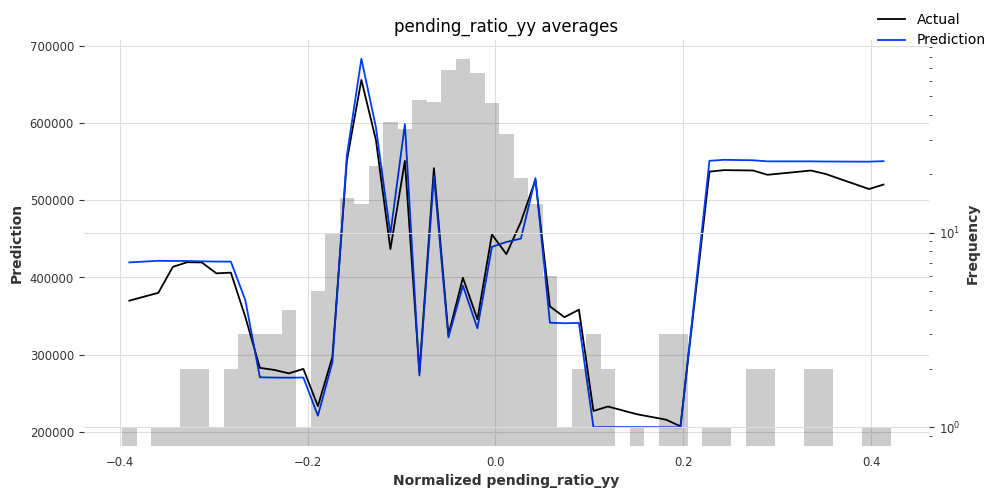

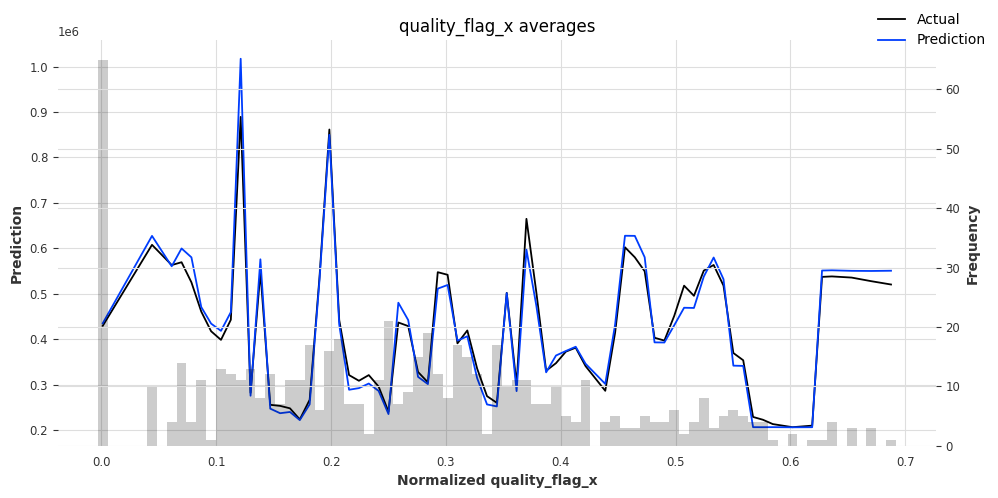

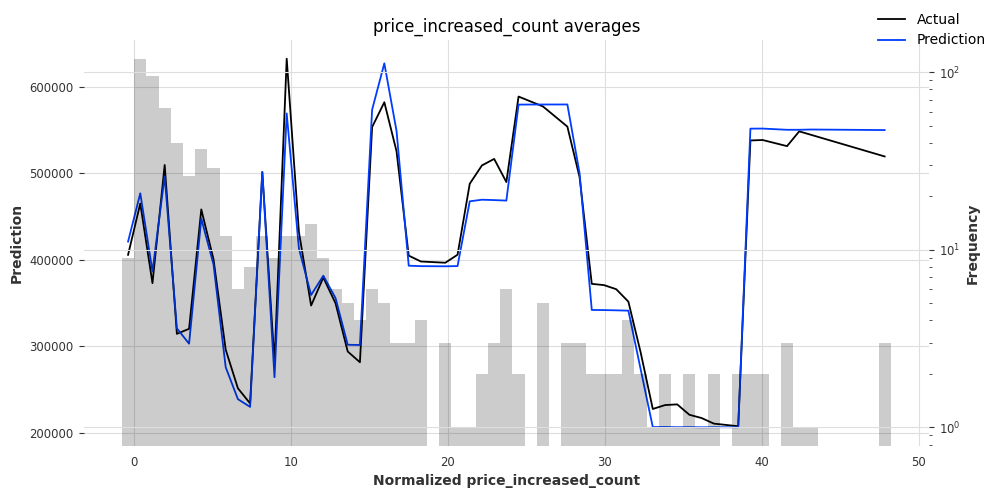

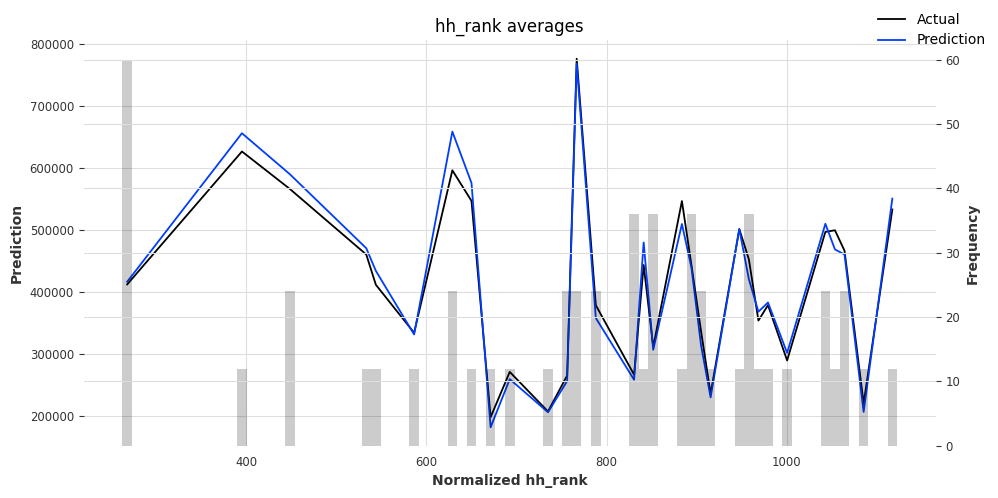

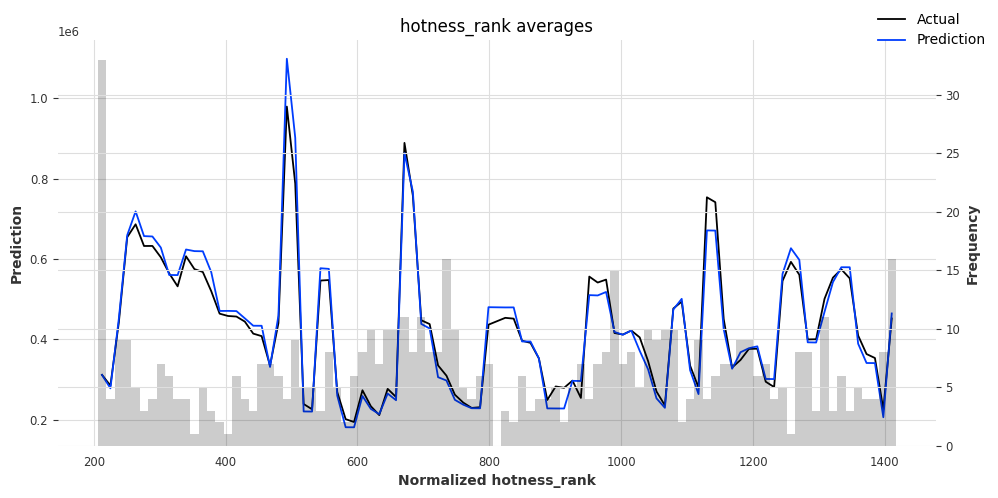

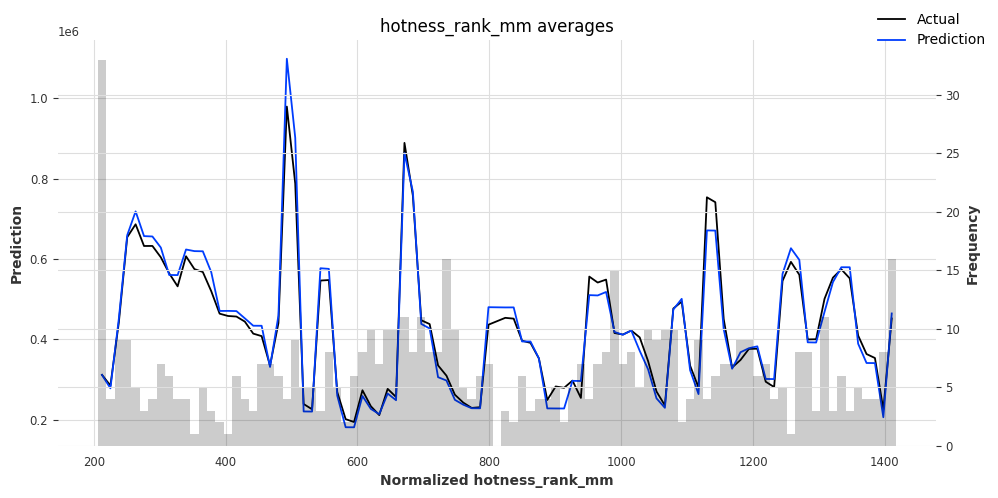

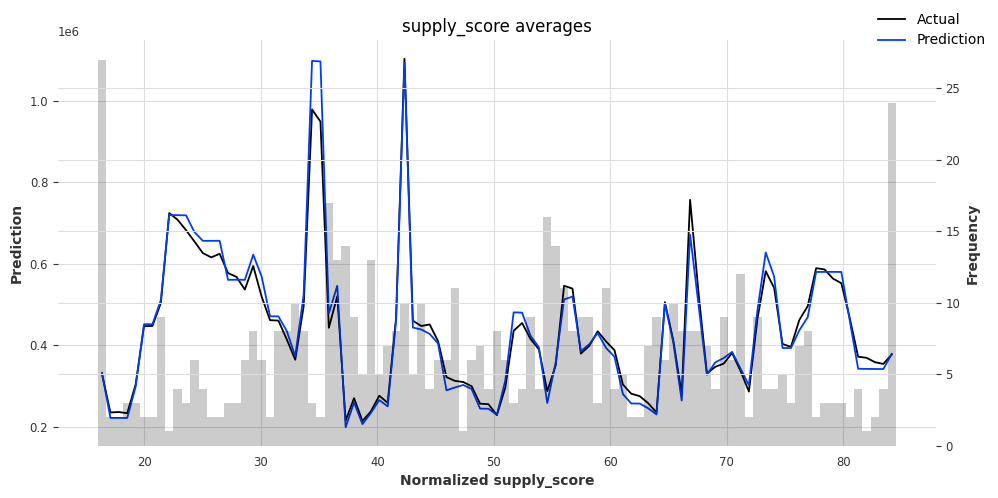

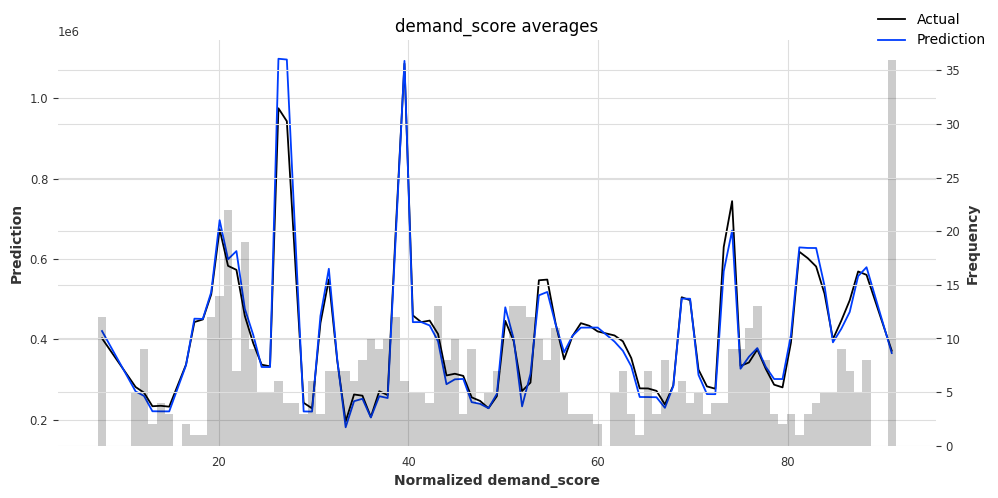

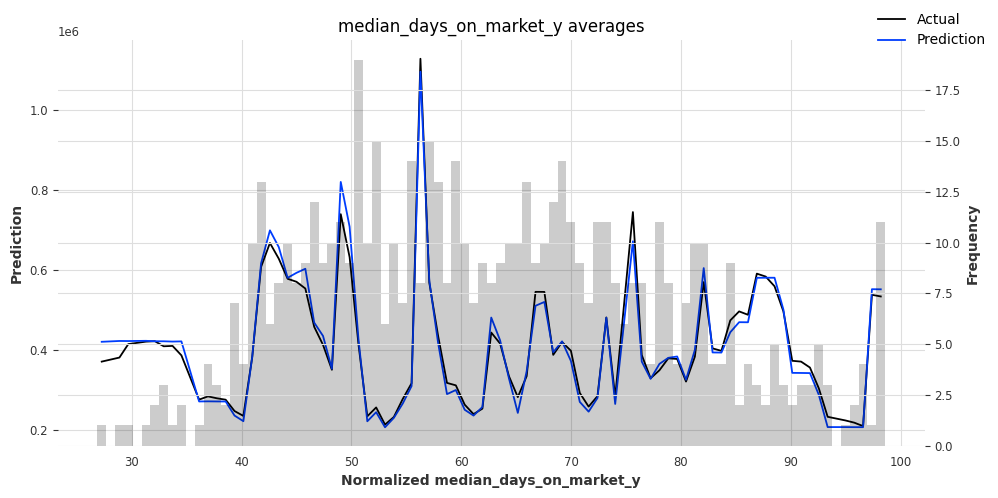

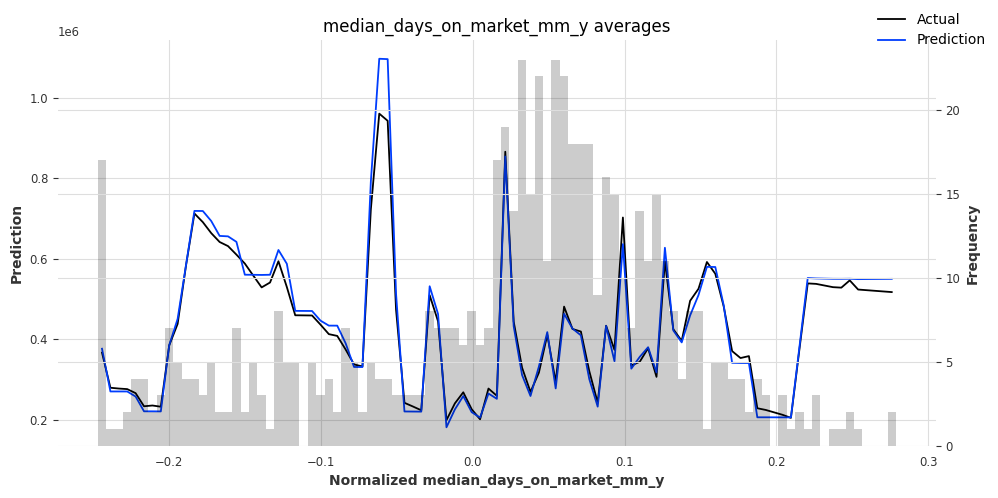

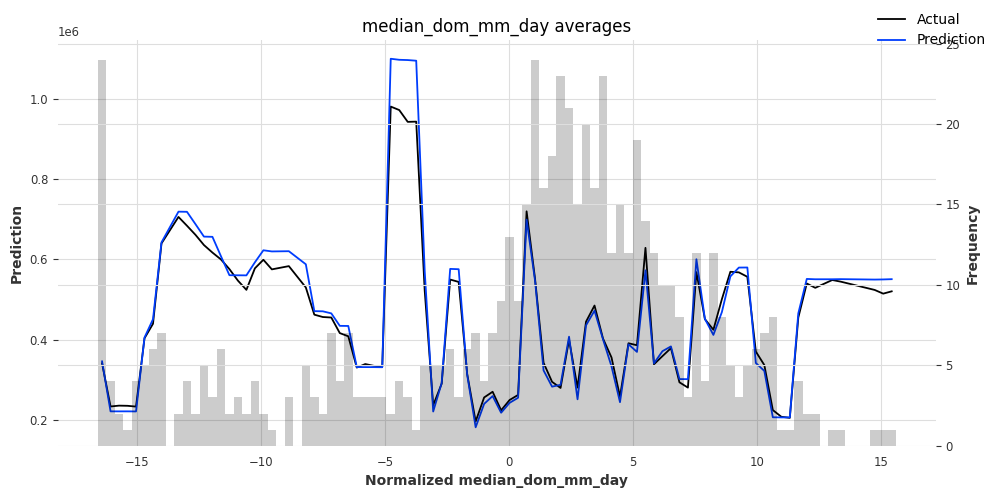

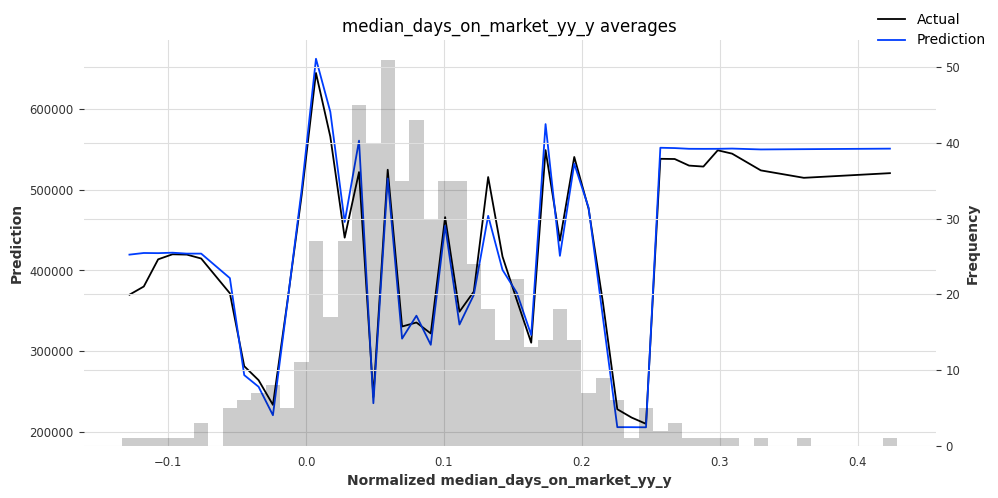

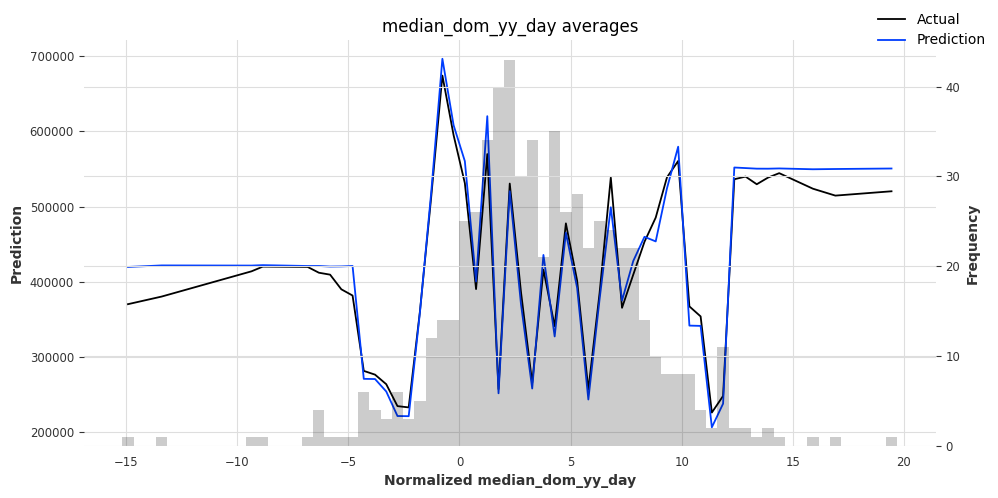

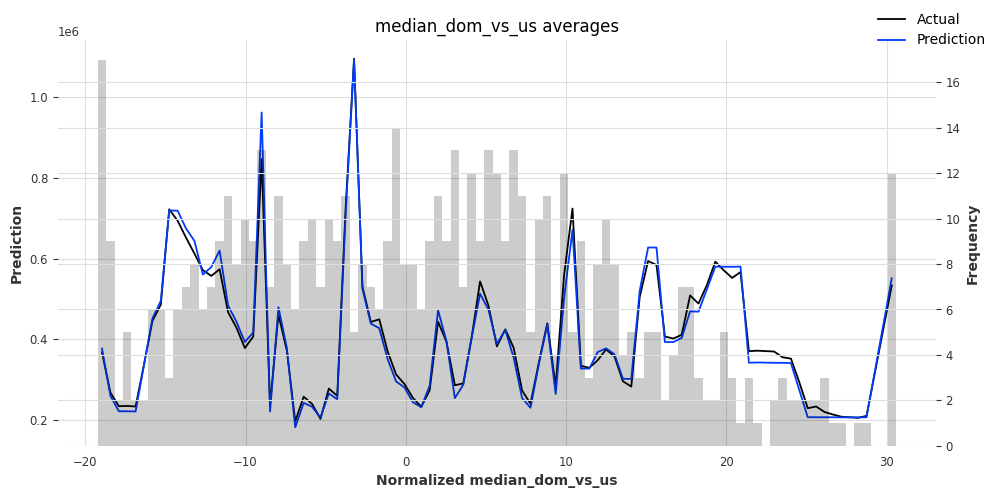

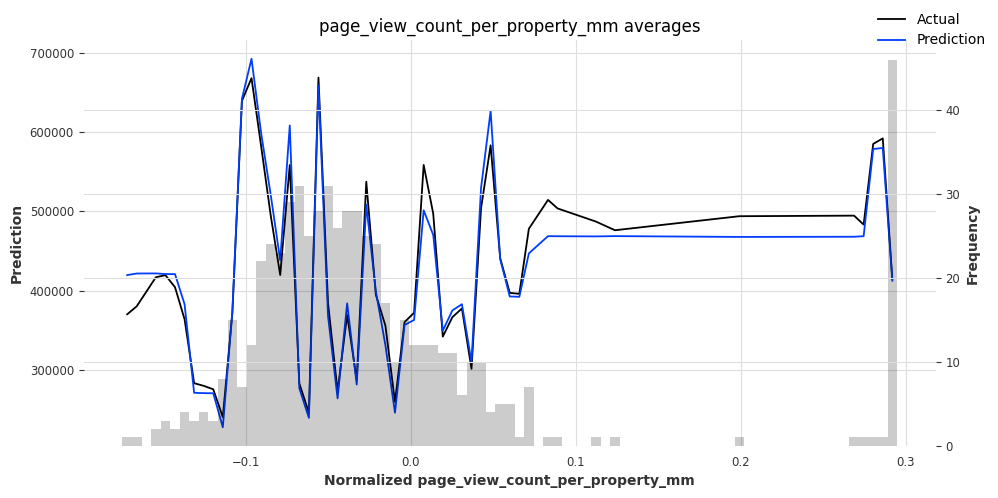

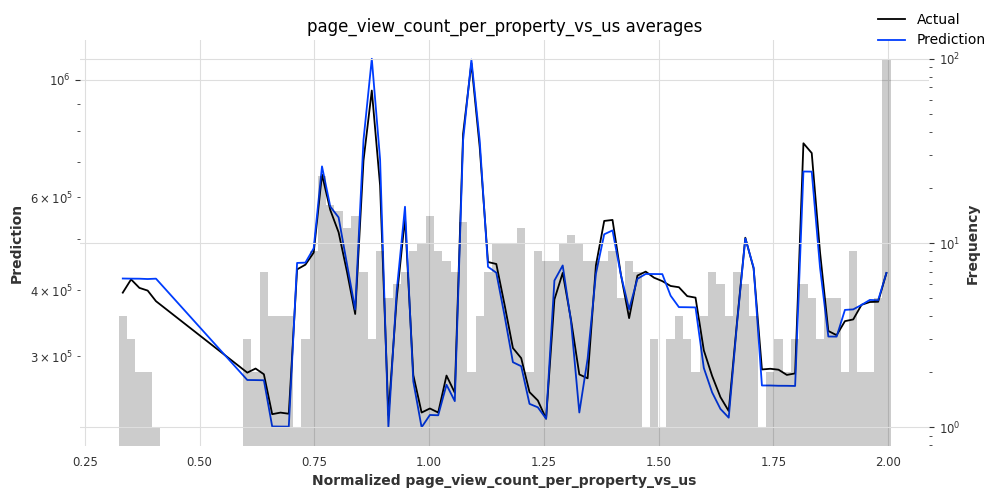

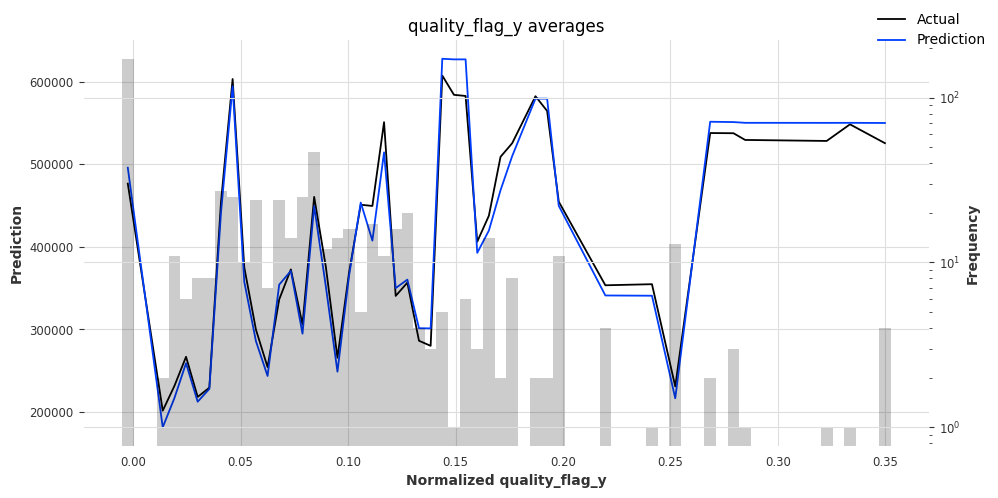

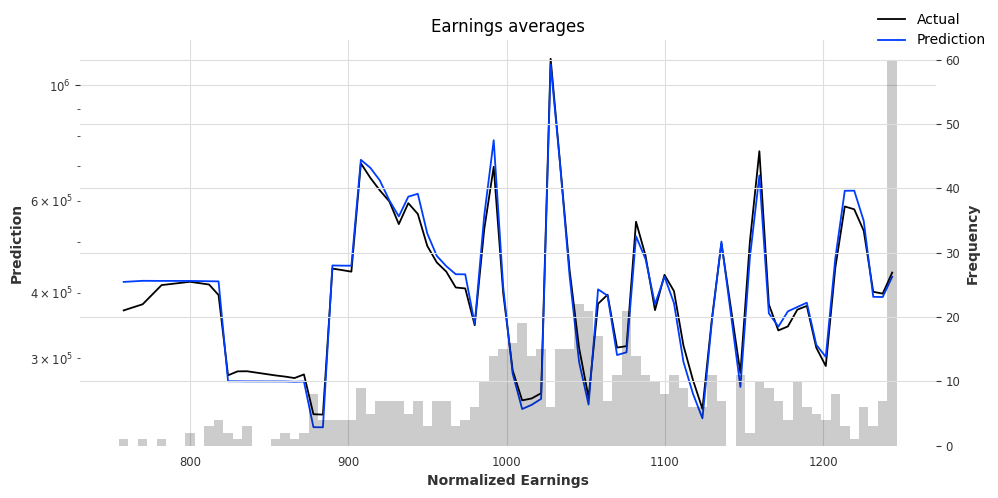

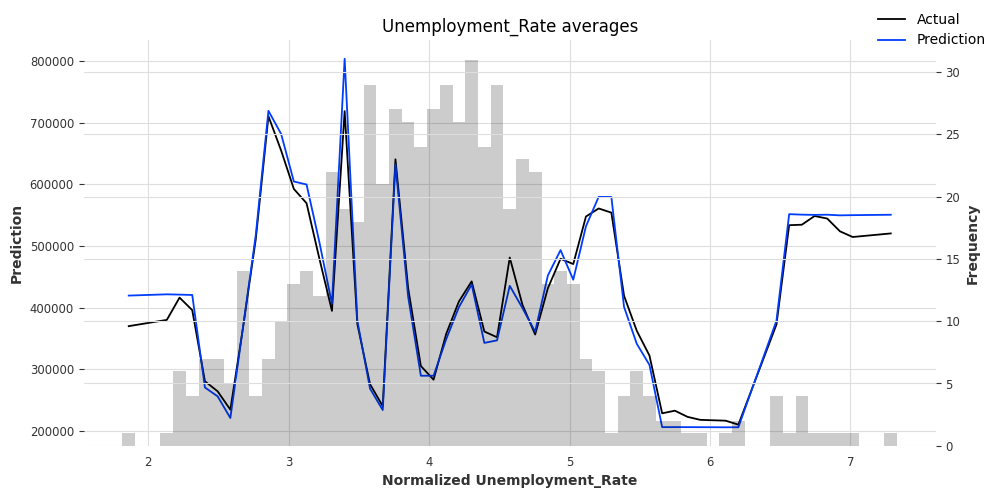

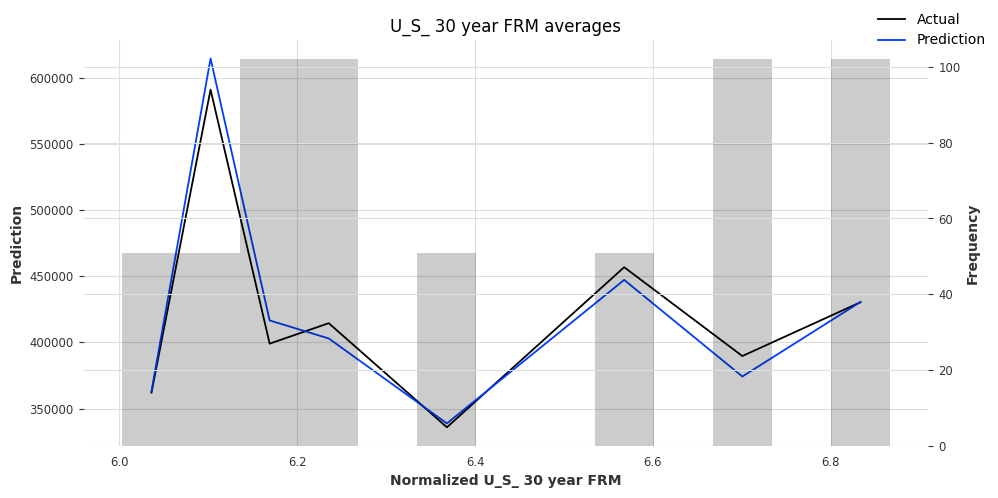

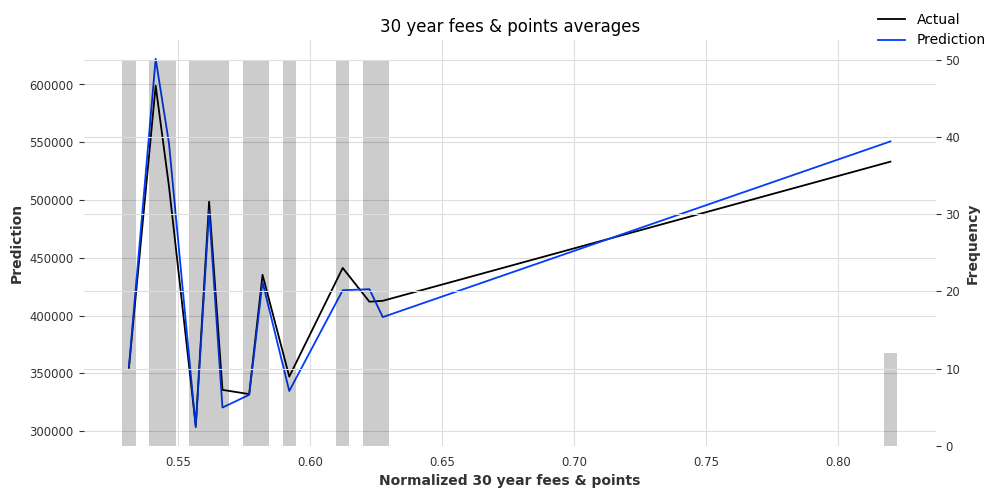

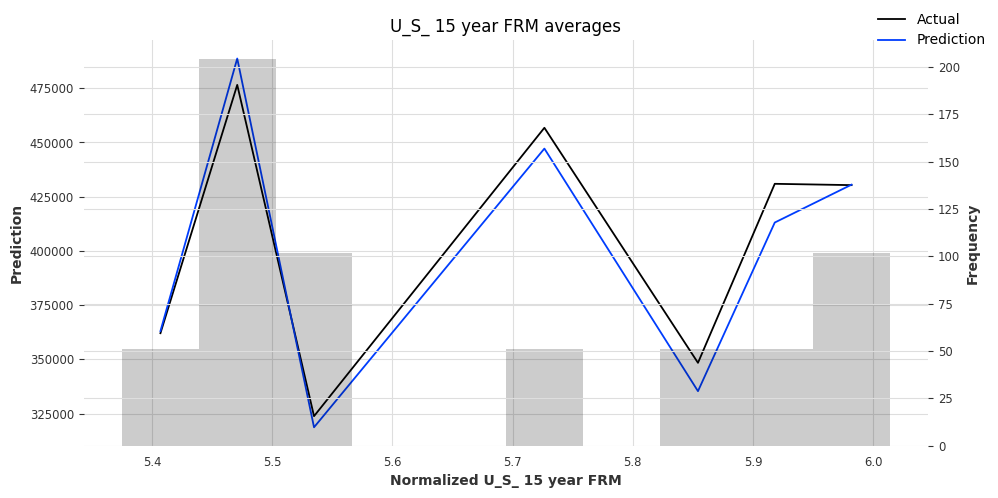

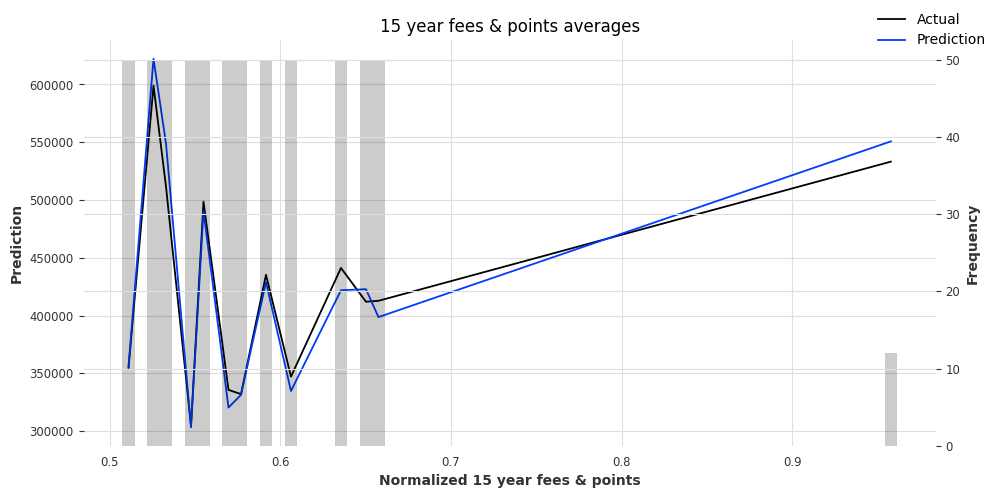

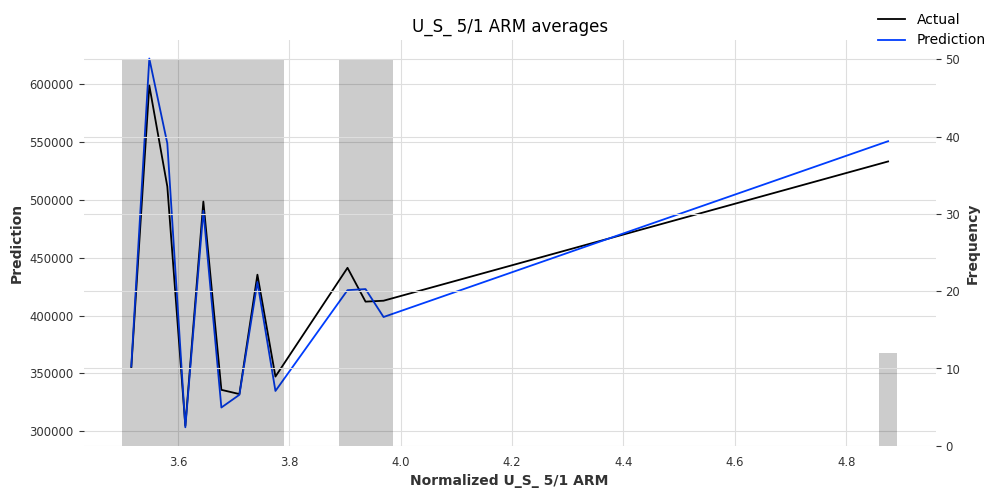

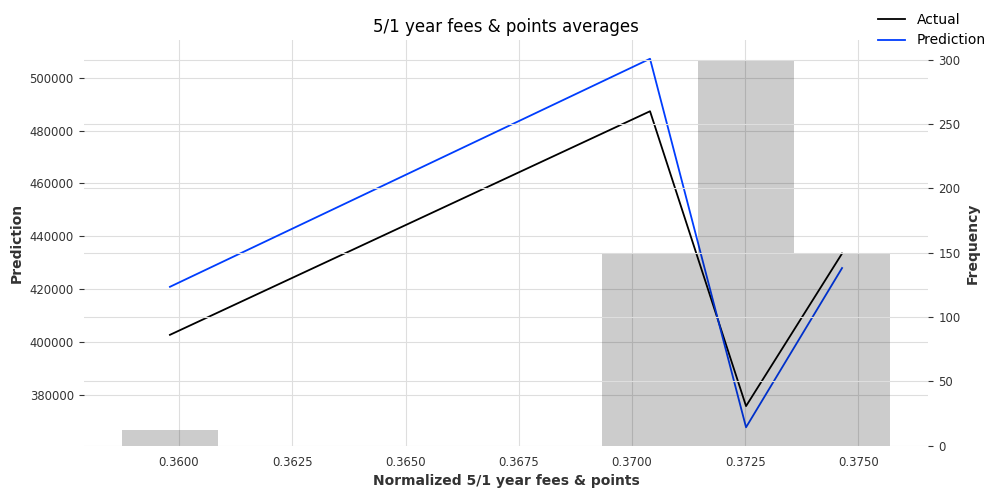

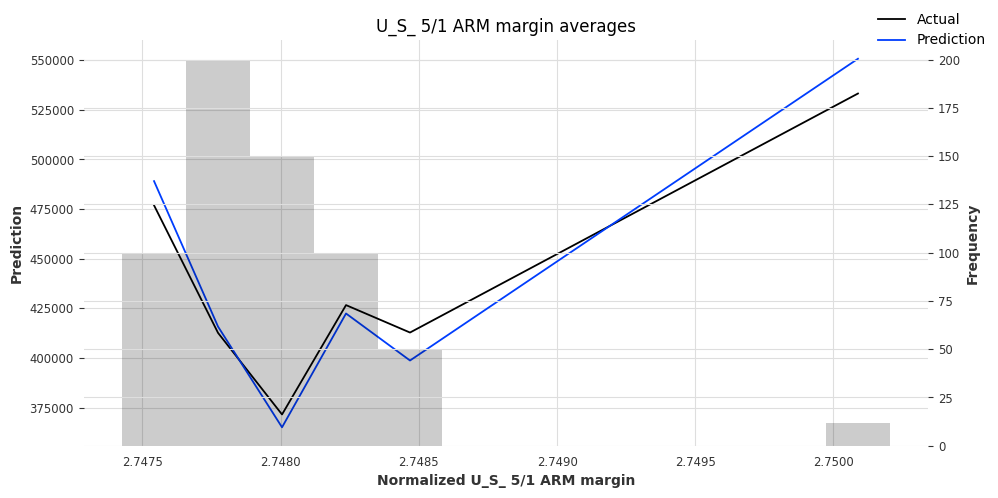

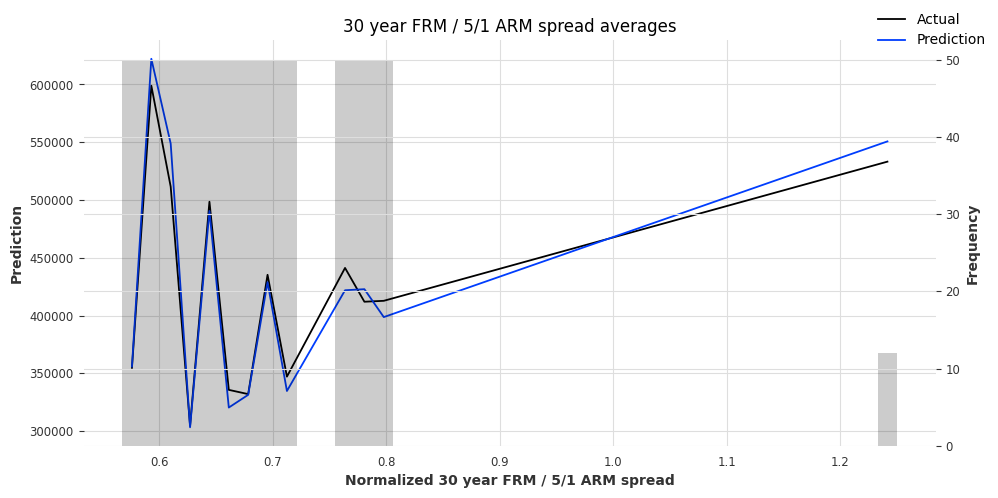

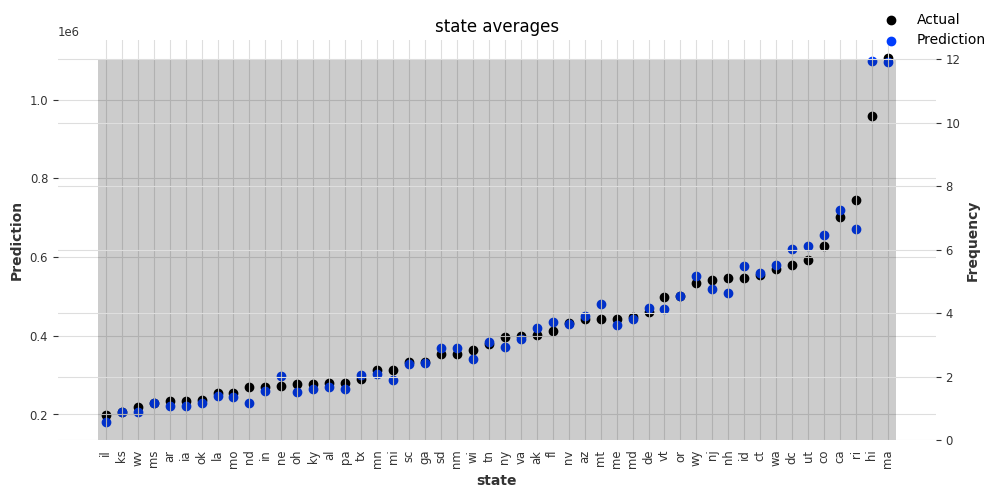

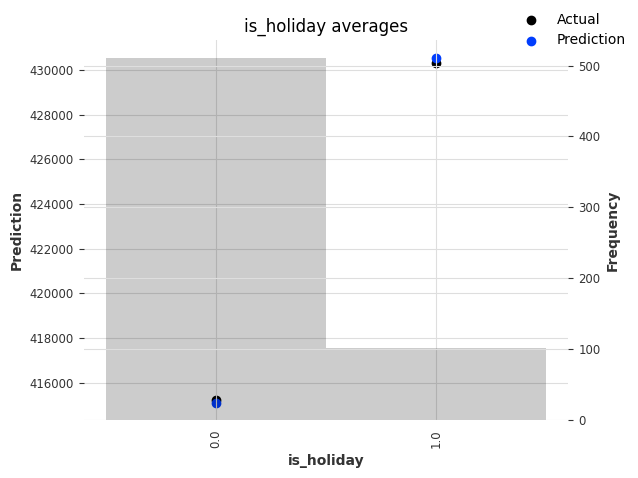

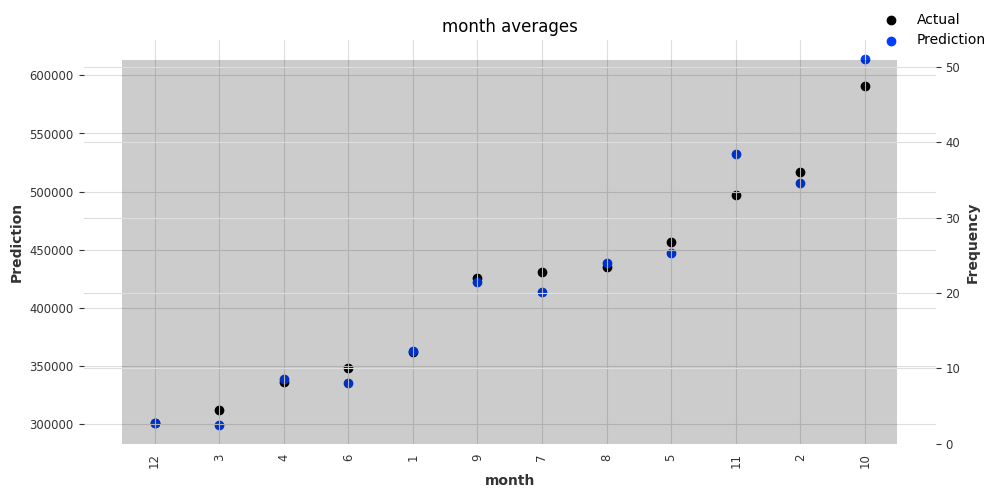

In [ ]:
predictions = best_tft.predict(
    val_dataloader, return_x=True, trainer_kwargs=dict(accelerator="cpu")
)
predictions_vs_actuals = best_tft.calculate_prediction_actual_by_variable(
    predictions.x, predictions.output
)
best_tft.plot_prediction_actual_by_variable(predictions_vs_actuals)

Predict on selected data

In [ ]:
best_tft.predict(
    training.filter(
        lambda x: (x.agency == "Agency_01")
        & (x.sku == "SKU_01")
        & (x.time_idx_first_prediction == 15)
    ),
    mode="quantiles",
    trainer_kwargs=dict(accelerator="cpu"),
)

AttributeError: 'DataFrame' object has no attribute 'agency'

In [ ]:
raw_prediction = best_tft.predict(
    training.filter(
        lambda x: (x.agency == "Agency_01")
        & (x.sku == "SKU_01")
        & (x.time_idx_first_prediction == 15)
    ),
    mode="raw",
    return_x=True,
    trainer_kwargs=dict(accelerator="cpu"),
)
best_tft.plot_prediction(raw_prediction.x, raw_prediction.output, idx=0)

Predict on new data

In [ ]:
# select last 24 months from data (max_encoder_length is 24)
encoder_data = data[lambda x: x.time_idx > x.time_idx.max() - max_encoder_length]

# select last known data point and create decoder data from it by repeating it and incrementing the month
# in a real world dataset, we should not just forward fill the covariates but specify them to account
# for changes in special days and prices (which you absolutely should do but we are too lazy here)
last_data = data[lambda x: x.time_idx == x.time_idx.max()]
decoder_data = pd.concat(
    [
        last_data.assign(date=lambda x: x.date + pd.offsets.MonthBegin(i))
        for i in range(1, max_prediction_length + 1)
    ],
    ignore_index=True,
)

# add time index consistent with "data"
decoder_data["time_idx"] = (
    decoder_data["date"].dt.year * 12 + decoder_data["date"].dt.month
)
decoder_data["time_idx"] += (
    encoder_data["time_idx"].max() + 1 - decoder_data["time_idx"].min()
)

# adjust additional time feature(s)
decoder_data["month"] = decoder_data.date.dt.month.astype(str).astype(
    "category"
)  # categories have be strings

# combine encoder and decoder data
new_prediction_data = pd.concat([encoder_data, decoder_data], ignore_index=True)

In [ ]:
new_raw_predictions = best_tft.predict(
    new_prediction_data,
    mode="raw",
    return_x=True,
    trainer_kwargs=dict(accelerator="cpu"),
)

for idx in range(10):  # plot 10 examples
    best_tft.plot_prediction(
        new_raw_predictions.x,
        new_raw_predictions.output,
        idx=idx,
        show_future_observed=False,
    )

Interpret model

{'attention': <Figure size 640x480 with 1 Axes>,
 'static_variables': <Figure size 700x300 with 1 Axes>,
 'encoder_variables': <Figure size 700x1725 with 1 Axes>,
 'decoder_variables': <Figure size 700x300 with 1 Axes>}

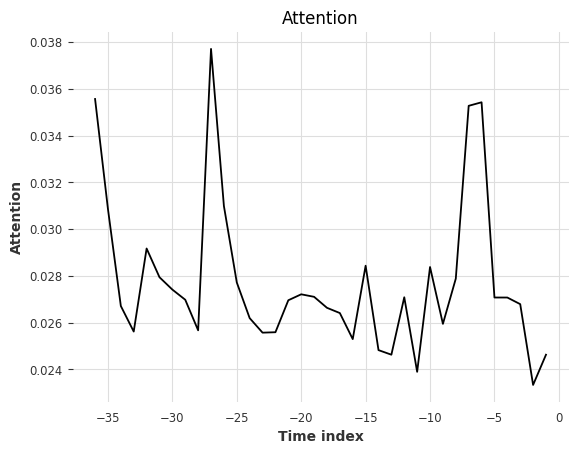

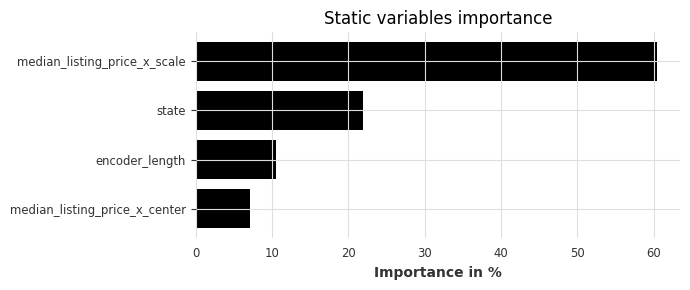

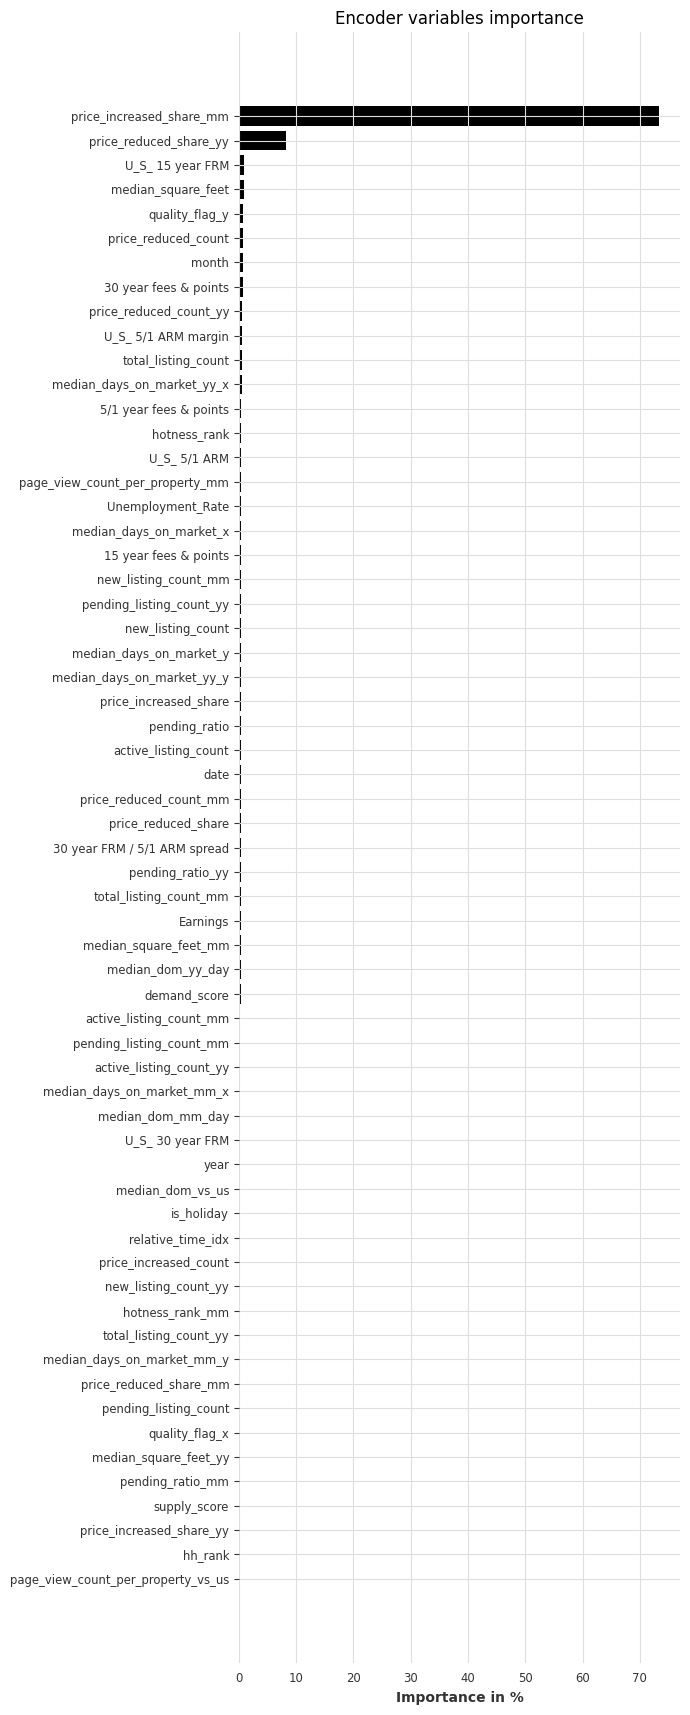

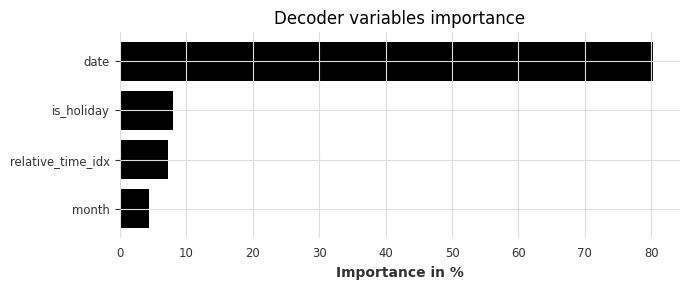

In [ ]:
interpretation = best_tft.interpret_output(raw_predictions.output, reduction="sum")
best_tft.plot_interpretation(interpretation)

Partial dependency

In [ ]:
dependency = best_tft.predict_dependency(
    val_dataloader.dataset,
    "discount_in_percent",
    np.linspace(0, 30, 30),
    show_progress_bar=True,
    mode="dataframe",
    trainer_kwargs=dict(accelerator="cpu"),
)

Predict:   0%|          | 0/30 [00:00<?, ? batches/s]

AssertionError: overwrite values variable has to be either in real or categorical variables

In [ ]:
# plotting median and 25% and 75% percentile
agg_dependency = dependency.groupby("discount_in_percent").normalized_prediction.agg(
    median="median", q25=lambda x: x.quantile(0.25), q75=lambda x: x.quantile(0.75)
)
ax = agg_dependency.plot(y="median")
ax.fill_between(agg_dependency.index, agg_dependency.q25, agg_dependency.q75, alpha=0.3)

# Save model

In [ ]:
# Save darts model using its native method (handles PyTorch internals)
model.save('../src/model_pt/tft_model_lod.pt')

In [ ]:
# load model
if not hasattr(torch, '_true_load'):
    torch._true_load = torch.load
torch.load = lambda *args, **kwargs: torch._true_load(*args, **{**kwargs, 'weights_only': False})
try:
    model = TFTModel.load('../src/model_pt/tft_model_lod.pt')
finally:
    torch.load = torch._true_load

- Need to understand this

In [ ]:
# Evaluate: predict for each state, compute per-state MAPE
state_preds = {}
state_mapes = {}

for i, (state_name, data) in enumerate(state_results.items()):
    
    pred = eval_model.predict(
        n=len(data['val_transformed']),
        series=data['train_transformed'],
        future_covariates=data['future_cov_transformed'],
        past_covariates=data['past_cov_transformed'],
        num_samples=num_samples,
        verbose=False
    )
    state_preds[state_name] = pred
    state_mapes[state_name] = mape(data['val_transformed'], pred)

# Summary stats
mape_values = list(state_mapes.values())
print(f"State-level MAPE across {len(mape_values)} states:")
print(f"  Mean:   {np.mean(mape_values):.2f}%")
print(f"  Median: {np.median(mape_values):.2f}%")
print(f"  Min:    {np.min(mape_values):.2f}%")
print(f"  Max:    {np.max(mape_values):.2f}%")

# --- Aggregate state predictions to national level ---
from functools import reduce

national_actual_dfs = []
national_pred_samples = []  # keep all samples for quantile bands

for state_name, data in state_results.items():
    scaler = data['scaler_target']
    pred_inv = scaler.inverse_transform(state_preds[state_name])
    
    # Full actual series (train + val), not just validation
    full_inv = scaler.inverse_transform(data['series_transformed'])
    full_df = full_inv.to_dataframe()
    full_df.columns = [state_name]
    national_actual_dfs.append(full_df)
    
    # Keep all samples (shape: timesteps x 1 x num_samples) for quantile aggregation
    national_pred_samples.append(pred_inv.all_values())  # numpy array

# Full actual series averaged across states
national_actual_df = pd.concat(national_actual_dfs, axis=1).mean(axis=1).to_frame('median_listing_price_x')
national_actual_ts = TimeSeries.from_dataframe(national_actual_df, freq='MS')

# Average prediction samples across states → preserves quantile information
# Each element is (n_timesteps, 1, num_samples); stack and mean over states
national_pred_arr = np.mean(np.array(national_pred_samples), axis=0)  # (n_timesteps, 1, num_samples)

# Build a probabilistic TimeSeries from the averaged samples
if not state_preds:
    raise ValueError("state_preds is empty — no predictions were generated. Ensure eval_model.predict ran successfully.")
pred_time_index = next(iter(state_preds.values())).time_index
national_pred_ts = TimeSeries.from_times_and_values(
    times=pred_time_index,
    values=national_pred_arr,
)

national_actual_sliced = national_actual_ts.slice(national_pred_ts.start_time(), national_pred_ts.end_time())
national_train_ts = national_actual_ts.slice(
    national_actual_ts.start_time(),
    national_pred_ts.start_time() - pd.DateOffset(months=1),
)

national_mape = mape(national_actual_sliced, national_pred_ts)
national_rmse = rmse(national_actual_sliced, national_pred_ts)
national_mae = mae(national_actual_sliced, national_pred_ts)
national_mase = mase(national_actual_sliced, national_pred_ts, insample=national_train_ts, m=12)

print(f"\n  (USA) national aggregated MAPE: {national_mape:.2f}%")
print(f"  (USA) national aggregated RMSE: {national_rmse:,.0f}")
print(f"  (USA) national aggregated MAE:  {national_mae:,.0f}")
print(f"  (USA) national aggregated MASE: {national_mase:.2f}")

# Plot national-level result with full actuals and quantile bands
plt.figure(figsize=figsize)
national_actual_ts.plot(label="actual (state avg)")
national_pred_ts.plot(low_quantile=low_q, high_quantile=high_q, label=label_q_inner)
plt.title(f"USA Forecast (state to national aggregation) - MAPE: {national_mape:.2f}%, RMSE: {national_rmse:,.0f}, MAE: {national_mae:,.0f}, MASE: {national_mase:.2f}")
plt.legend()